# 01 — Molecular Structure, HF, DFT & Basis Sets

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/01_molecular_structure_and_basis_sets.ipynb)

## 🎯 Learning Objectives


- Slater-type (STO) and Gaussian-type (GTO) orbitals/basis functions
- Basis set families and understand accuracy/cost trade-offs
- Basis set convergence for total energies
- Contracted vs primitive basis functions
- Effective core potentials (ECPs) and when to use them
- Atomic orbital radial probability distributions

## 1. Theory: Basis Functions in Quantum Chemistry

### 1.1 Slater-Type Orbitals (STOs)

The exact hydrogen-like atomic orbitals are Slater-type orbitals (STOs):

$$\chi_{nlm}(r,\theta,\phi) = N r^{n-1} e^{-\zeta r} Y_l^m(\theta,\phi)$$

where:
- $N$ = normalization constant
- $n$ = principal quantum number
- $\zeta$ (zeta) = orbital exponent controlling size
- $Y_l^m$ = spherical harmonic

**Advantages:** Correct cusp at nucleus, correct exponential decay
**Disadvantage:** Multi-center two-electron integrals are very expensive (no analytic formula)

### 1.2 Gaussian-Type Orbitals (GTOs)

In practice, we use Gaussian-type orbitals (GTOs):

$$g_{lmn}(\mathbf{r}; \alpha) = N x^l y^m z^n e^{-\alpha r^2}$$

where $\alpha$ is the Gaussian exponent and $l+m+n$ determines the angular momentum.

**Advantage:** Products of Gaussians are Gaussians → all integrals are analytic!
**Disadvantage:** Incorrect behavior at nucleus (no cusp) and at long range (decays too fast)

### 1.3 Contracted Basis Sets

To capture STO-like behavior, we use **contracted** basis functions:
$$\chi_\mu = \sum_k d_{k\mu} g_k$$

A **contraction** combines multiple primitive Gaussians ($g_k$) with fixed coefficients ($d_{k\mu}$) to form a single basis function. For example, STO-3G uses 3 Gaussians to approximate each STO.

### 1.4 Basis Set Families

| Family | Strategy | Example |
|--------|----------|---------|
| **Pople** | Add shells systematically | 6-31G, 6-31G\*, 6-311G\*\* |
| **Dunning** (cc-pVxZ) | Converges to CBS limit | cc-pVDZ, cc-pVTZ, cc-pVQZ |
| **Ahlrichs** (def2) | Balanced accuracy/cost | def2-SVP, def2-TZVP, def2-QZVP |

**Notation:**
- **DZ** (double-ζ), **TZ** (triple-ζ), **QZ** (quadruple-ζ): number of basis functions per orbital
- **\*** or **P**: adds polarization functions (e.g., d functions on C, N, O)
- **aug-**: adds diffuse functions (needed for anions, excited states, weak interactions)

In [1]:
# =============================================================================
# Ch121a: Quantum Chemistry & DFT — Notebook 01: Molecular Structure & Basis Sets
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyscf import gto, scf

  STO-3G        N=  7  E = -74.96293261 Ha
  3-21G         N= 13  E = -75.58539445 Ha
  6-31G*        N= 18  E = -76.00913108 Ha
  cc-pVDZ       N= 24  E = -76.02679684 Ha
  cc-pVTZ       N= 58  E = -76.05716610 Ha
  def2-SVP      N= 24  E = -75.96101285 Ha
  def2-TZVP     N= 43  E = -76.05904087 Ha


Basis Set  N_basis  E_HF (Ha)   E_HF (eV)
   STO-3G        7 -74.962933 -2039.84634
    3-21G       13 -75.585394 -2056.78440
   6-31G*       18 -76.009131 -2068.31487
  cc-pVDZ       24 -76.026797 -2068.79558
  cc-pVTZ       58 -76.057166 -2069.62197
 def2-SVP       24 -75.961013 -2067.00551
def2-TZVP       43 -76.059041 -2069.67298

cc-pVTZ - STO-3G energy difference: -686.64 kcal/mol


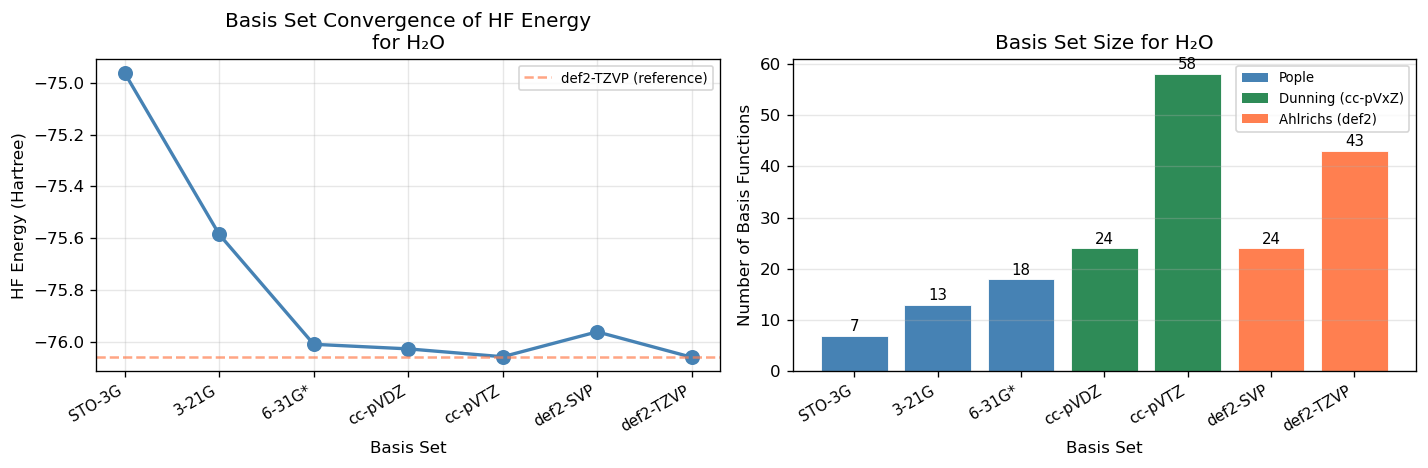

CPU times: user 11.6 s, sys: 60.6 ms, total: 11.6 s
Wall time: 3.54 s


In [2]:
%%time
# ------------------------------------------------------------------
# Basis set convergence study for water (H2O)
# ------------------------------------------------------------------
# We compare HF energies across a range of basis sets to see
# how the energy converges toward the complete basis set (CBS) limit.

mol_template = """
O   0.000000   0.000000   0.117176
H   0.000000   0.757001  -0.468704
H   0.000000  -0.757001  -0.468704
"""

basis_sets = ['STO-3G', '3-21G', '6-31G*', 'cc-pVDZ', 'cc-pVTZ', 'def2-SVP', 'def2-TZVP']

results = []
for basis in basis_sets:
    mol = gto.Mole()
    mol.atom = mol_template
    mol.basis = basis
    mol.verbose = 0
    mol.build()
    mf = scf.RHF(mol)
    mf.verbose = 0
    e = mf.kernel()
    n_bas = mol.nao_nr()
    results.append({'Basis Set': basis, 'N_basis': n_bas,
                    'E_HF (Ha)': round(e, 8), 'E_HF (eV)': round(e*27.2114, 5)})
    print(f"  {basis:12s}  N={n_bas:3d}  E = {e:.8f} Ha")

df = pd.DataFrame(results)
print("\n")
print(df.to_string(index=False))
print(f"\ncc-pVTZ - STO-3G energy difference: {(results[4]['E_HF (Ha)']-results[0]['E_HF (Ha)'])*627.509:.2f} kcal/mol")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

energies = [r['E_HF (Ha)'] for r in results]
n_basis = [r['N_basis'] for r in results]
labels = [r['Basis Set'] for r in results]

# Panel 1: Energy vs basis set
ax1.plot(range(len(basis_sets)), energies, 'o-', color='steelblue',
         linewidth=2, markersize=8)
ax1.axhline(y=energies[-1], color='coral', linestyle='--', alpha=0.7, label='def2-TZVP (reference)')
ax1.set_xticks(range(len(basis_sets)))
ax1.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax1.set_xlabel('Basis Set')
ax1.set_ylabel('HF Energy (Hartree)')
ax1.set_title('Basis Set Convergence of HF Energy\nfor H₂O')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2: Number of basis functions vs basis set
colors = ['steelblue' if 'STO' in b or '3-21' in b or '6-31G*' in b else
          'seagreen' if 'cc-p' in b else 'coral' for b in labels]
bars = ax2.bar(range(len(basis_sets)), n_basis, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(len(basis_sets)))
ax2.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax2.set_xlabel('Basis Set')
ax2.set_ylabel('Number of Basis Functions')
ax2.set_title('Basis Set Size for H₂O')
ax2.grid(True, alpha=0.3, axis='y')
for bar, n in zip(bars, n_basis):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(n), ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Pople'),
                   Patch(facecolor='seagreen', label='Dunning (cc-pVxZ)'),
                   Patch(facecolor='coral', label='Ahlrichs (def2)')]
ax2.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.show()

I showed this earlier as well in notebook 1 where I compared 5 basis sets. The more flexible our orbitals are we are better in the real value according to the variational principle. Though there is a tradeoff

In [3]:
# ------------------------------------------------------------------
# Effective Core Potentials (ECPs)
# ------------------------------------------------------------------
# For heavy elements (3d, 4d, 5d transition metals, lanthanides),
# the core electrons are chemically inert and their relativistic
# effects can be captured via an ECP (pseudopotential).

from pyscf import gto

# Demonstrate ECP for Iron (Fe, Z=26)
mol_Fe = gto.Mole()
mol_Fe.atom = 'Fe 0 0 0'
mol_Fe.basis = 'def2-SVP'
mol_Fe.ecp = 'def2-SVP'     # Use the def2-SVP ECP for Fe
mol_Fe.verbose = 0
mol_Fe.build()

print("=" * 55)
print("  Effective Core Potential (ECP) Demonstration: Fe")
print("=" * 55)
print(f"  Element:                        Fe (Z = 26)")
print(f"  ECP:                            def2-SVP")
print(f"  Core electrons replaced by ECP: {mol_Fe.atom_nelec_core(0)}")
print(f"  Valence electrons treated:      {mol_Fe.nelectron}")
print(f"  Basis functions (valence only): {mol_Fe.nao_nr()}")

# Compare with all-electron def2-SVP (no ECP)
mol_Fe_ae = gto.Mole()
mol_Fe_ae.atom = 'Fe 0 0 0'
mol_Fe_ae.basis = 'def2-SVP'
mol_Fe_ae.verbose = 0
mol_Fe_ae.build()
print(f"\n  All-electron comparison:")
print(f"  All electrons:                  {mol_Fe_ae.nelectron}")
print(f"  Basis functions (all-electron): {mol_Fe_ae.nao_nr()}")

print("\nWhen to use ECPs:")
print("  • Elements beyond Kr (Z > 36): relativistic effects important")
print("  • 3d metals: saves ~10 core electrons per atom")
print("  • 4d/5d metals: saves ~28/60 core electrons per atom")
print("  • Lanthanides/Actinides: ECP is essentially mandatory")

  Effective Core Potential (ECP) Demonstration: Fe
  Element:                        Fe (Z = 26)
  ECP:                            def2-SVP
  Core electrons replaced by ECP: 0
  Valence electrons treated:      26
  Basis functions (valence only): 31

  All-electron comparison:
  All electrons:                  26
  Basis functions (all-electron): 31

When to use ECPs:
  • Elements beyond Kr (Z > 36): relativistic effects important
  • 3d metals: saves ~10 core electrons per atom
  • 4d/5d metals: saves ~28/60 core electrons per atom
  • Lanthanides/Actinides: ECP is essentially mandatory


ECP def2-SVP not found for  Fe


In [6]:
from pyscf import gto

# ── Mo (Z=42) ─ correctly uses def2-ECP ──────────────────────────
mol_Mo = gto.Mole()
mol_Mo.atom  = 'Mo 0 0 0'       # Bug fix 1: was 'Fe'
mol_Mo.basis = 'def2-SVP'
mol_Mo.ecp   = 'def2-SVP'       # PySCF accepts 'def2-SVP' or 'def2-ecp'
mol_Mo.spin  = 6                 # Mo ground state: [Kr] 4d5 5s1, S=3
mol_Mo.verbose = 0
mol_Mo.build()

print("=" * 55)
print("  ECP Demonstration: Mo (Z=42)")
print("=" * 55)
print(f"  ECP:                            def2-SVP")
print(f"  Core electrons replaced:        {mol_Mo.atom_nelec_core(0)}")  # → 28
print(f"  Valence electrons treated:      {mol_Mo.nelectron}")
print(f"  Basis functions (valence only): {mol_Mo.nao_nr()}")

# ── Fe (Z=26) ─ all-electron, no ECP needed ──────────────────────
mol_Fe_ae = gto.Mole()
mol_Fe_ae.atom    = 'Fe 0 0 0'
mol_Fe_ae.basis   = 'def2-SVP'   # NO mol.ecp line — all-electron
mol_Fe_ae.spin    = 4            # Fe ground state: [Ar] 3d6 4s2, S=2
mol_Fe_ae.verbose = 0
mol_Fe_ae.build()

print(f"\n  All-electron Fe (Z=26) with def2-SVP:")
print(f"  All electrons:                  {mol_Fe_ae.nelectron}")  # → 26
print(f"  Core electrons (ECP):           {mol_Fe_ae.atom_nelec_core(0)}")  # → 0
print(f"  Basis functions:                {mol_Fe_ae.nao_nr()}")

  ECP Demonstration: Mo (Z=42)
  ECP:                            def2-SVP
  Core electrons replaced:        28
  Valence electrons treated:      14
  Basis functions (valence only): 31

  All-electron Fe (Z=26) with def2-SVP:
  All electrons:                  26
  Core electrons (ECP):           0
  Basis functions:                31


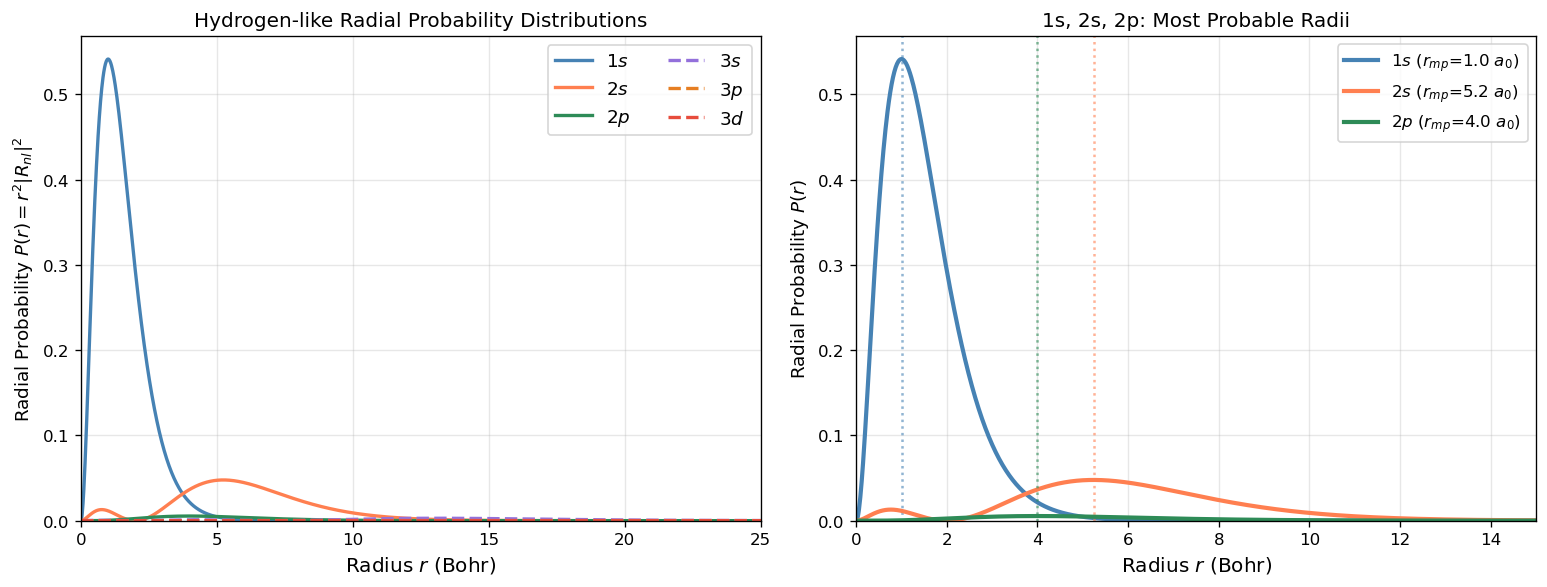


Note: 1 Bohr = 0.529 Å
Most probable radius for 1s: 1 Bohr (= Bohr radius a₀)


In [7]:
# ------------------------------------------------------------------
# Radial Probability Distributions of Hydrogen-like Orbitals
# ------------------------------------------------------------------
# P(r) = r^2 |R_nl(r)|^2  (probability per unit radius)

import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import factorial, genlaguerre

def hydrogen_radial(n, l, r, Z=1):
    """Normalized radial wavefunction R_nl(r) for hydrogen-like atom."""
    rho = 2 * Z * r / n
    # Normalization constant
    norm = np.sqrt((2*Z/n)**3 * factorial(n-l-1) /
                   (2*n * factorial(n+l)**3))
    # Associated Laguerre polynomial
    L = genlaguerre(n-l-1, 2*l+1)(rho)
    return norm * np.exp(-rho/2) * rho**l * L

r = np.linspace(0.001, 30, 2000)  # Bohr radii

orbitals = [
    (1, 0, '1s', 'steelblue',   '-'),
    (2, 0, '2s', 'coral',        '-'),
    (2, 1, '2p', 'seagreen',    '-'),
    (3, 0, '3s', 'mediumpurple', '--'),
    (3, 1, '3p', '#E67E22',      '--'),
    (3, 2, '3d', '#E74C3C',      '--'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: all orbitals together
ax = axes[0]
for n, l, label, color, ls in orbitals:
    R = hydrogen_radial(n, l, r)
    P = r**2 * R**2
    ax.plot(r, P, label=f'${label}$', color=color, linestyle=ls, linewidth=2)
ax.set_xlim(0, 25)
ax.set_ylim(bottom=0)
ax.set_xlabel('Radius $r$ (Bohr)', fontsize=12)
ax.set_ylabel('Radial Probability $P(r) = r^2|R_{nl}|^2$', fontsize=11)
ax.set_title('Hydrogen-like Radial Probability Distributions', fontsize=12)
ax.legend(fontsize=11, ncol=2)
ax.grid(True, alpha=0.3)

# Right plot: n=1,2,3 s orbitals only (compare size)
ax2 = axes[1]
for n, l, label, color, ls in orbitals[:3]:
    R = hydrogen_radial(n, l, r)
    P = r**2 * R**2
    # Mark the most probable radius
    r_mp = r[np.argmax(P)]
    ax2.plot(r, P, label=f'${label}$ ($r_{{mp}}$={r_mp:.1f} $a_0$)',
             color=color, linewidth=2.5)
    ax2.axvline(x=r_mp, color=color, linestyle=':', alpha=0.6)
ax2.set_xlim(0, 15)
ax2.set_ylim(bottom=0)
ax2.set_xlabel('Radius $r$ (Bohr)', fontsize=12)
ax2.set_ylabel('Radial Probability $P(r)$', fontsize=11)
ax2.set_title('1s, 2s, 2p: Most Probable Radii', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\nNote: 1 Bohr = 0.529 Å")
print("Most probable radius for 1s: 1 Bohr (= Bohr radius a₀)")

## 2. Basis Set Reference Table

| Basis Set | Family | # Fcns (H₂O) | Cost | Accuracy | Best Use Case |
|-----------|--------|:------------:|:----:|:--------:|---------------|
| STO-3G | Pople minimal | 7 | ★ | ★ | Quick tests, teaching |
| 3-21G | Pople split-val | 13 | ★★ | ★★ | Qualitative trends |
| 6-31G\* | Pople + polariz | 19 | ★★ | ★★★ | Organic chemistry |
| 6-311G\*\* | Pople triple-ζ | 30 | ★★★ | ★★★★ | Improved properties |
| cc-pVDZ | Dunning DZ | 24 | ★★ | ★★★ | Correlated calculations |
| cc-pVTZ | Dunning TZ | 58 | ★★★★ | ★★★★ | High accuracy |
| aug-cc-pVDZ | Dunning aug-DZ | 41 | ★★★ | ★★★★ | Anions, polarizability |
| def2-SVP | Ahlrichs SVP | 24 | ★★ | ★★★ | DFT, geometry opt |
| def2-TZVP | Ahlrichs TZV | 58 | ★★★★ | ★★★★★ | Production DFT |

**For known systems:**
- Start with **def2-SVP** for geometry optimizations
- Use **def2-TZVP** for final energies and properties
- Use **cc-pVTZ** or higher for correlated calculations (MP2, CCSD)
- Add **aug-** prefix for anions, Rydberg states, polarizabilities, NMR
- Use **ECPs** (def2-SVP/TZVP) for transition metals and heavy elements

## 🔬 Research Connection

Basis set choice is critical in published computational chemistry papers:

- **Protein active sites**: def2-SVP is often used for QM/MM calculations on enzyme
  active sites (50-200 atoms in the QM region) due to its cost/accuracy balance.
- **CBS extrapolation**: High-accuracy thermochemistry (e.g., W4 theory, HEAT protocol)
  uses cc-pVDZ through cc-pV5Z with extrapolation to the complete basis set limit.
- **ORCA defaults**: ORCA uses def2-SVP as the default basis for geometry optimization
  and def2-TZVP for single-point energies — matching our course workflow.

**More basis sets/across codes:** The EMSL Basis Set Exchange (https://www.basissetexchange.org/)
provides basis sets in formats for all major QC programs.

## 📋 Summary

- **STOs** are physically correct but computationally expensive; **GTOs** are analytically tractable and used in all modern codes
- **Contracted** basis functions = fixed combinations of primitives; reduce computational cost
- **Convergence hierarchy**: STO-3G < 3-21G < 6-31G\* < cc-pVDZ < cc-pVTZ ← HF limit
- **Polarization functions** (\*) are essential for geometry and properties
- **Diffuse functions** (aug-) needed for anions, excited states, and weak interactions
- **ECPs** replace chemically inert core electrons in heavy elements with a potential

**Practical recommendation for this course:**
- Geometry optimization: **B3LYP/def2-SVP**
- Single-point energies: **B3LYP/def2-TZVP** or **PBE0/def2-TZVP**
- Heavy elements (3d metals): **def2-SVP** with ECP

## 📝 Some exercises

1. **STO-3G vs cc-pVTZ**: Run HF/STO-3G and HF/cc-pVTZ on CO₂. 
   What is the C=O bond length predicted by each? Compare with experimental 1.162 Å.
   (Hint: use `mol.atom = 'C 0 0 0; O 0 0 1.162; O 0 0 -1.162'`)

2. **Convergence plot**: Extend the basis set convergence study to include 
   `aug-cc-pVDZ` and `aug-cc-pVTZ`. How do the energies compare to the cc- series?

3. **ECP for copper**: Create a PySCF Mole object for Cu using def2-SVP with ECP.
   How many core electrons are replaced? How does this compare to Fe?

4. **Radial probability**: Modify the radial probability plot to show the 4s and 3d 
   orbitals. Why are these two orbitals similar in energy for transition metals?

5. **Basis set superposition error (BSSE)**: Look up the counterpoise correction method.
   Write pseudocode describing how you would estimate BSSE for the water dimer.

In [2]:
!pip install geometric

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 16.4 MB/s  0:00:00
  Created wheel for geometric: filename=geometric-1.1-py3-none-any.whl size=402174 sha256=6332956b6a4a8a946bee8c9696f05b311eace2684779e4b7bfa0840a23a58ef0
  Stored in directory: /home/dawood/.cache/pip/wheels/c5/77/0c/96a54539fe0560749fdbe283f92582d09bddb212856407a4cb
Successfully built geometric
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [geometric]/2 [geometric]


---

geometric-optimize called with the following command line:
/home/dawood/miniconda3/envs/ch121a-dft/lib/python3.11/site-packages/ipykernel_launcher.py -f /home/dawood/.local/share/jupyter/runtime/kernel-cc01c4fc-a5e1-4f20-8b35-42caed5831e9.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%/      *%%%%

Running HF/STO-3G geometry optimization for CO2


Step    0 : Gradient = 5.436e-02/6.658e-02 (rms/max) Energy = -185.0652201199
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 2.50000e-01 1.26494e+00 1.26494e+00
Step    1 : Displace = 2.274e-02/2.785e-02 (rms/max) Trust = 1.000e-01 (=) Grad = 3.685e-03/4.513e-03 (rms/max) E (change) = -185.0683740965 (-3.154e-03) Quality = 0.900
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 2.50000e-01 1.26494e+00 1.35067e+00
Step    2 : Displace = 1.444e-03/1.768e-03 (rms/max) Trust = 1.414e-01 (+) Grad = 3.057e-04/3.744e-04 (rms/max) E (change) = -185.0683904515 (-1.636e-05) Quality = 1.085
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 2.50000e-01 1.23862e+00 1.26494e+00
Step    3 : Displace = 1.306e-04/1.600e-04 (rms/max) Trust = 2.000e-01 (+) Grad = 2.052e-06/2.513e-06 (rms/max) E (change) = -185.0683905640 (-1.125e-07) Quality = 0.994
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 2.50000e-01 1.23862e+00 1.26494e+00
Converged! =D

    #====

Optimized C=O bond 1: 1.187925 Å
Optimized C=O bond 2: 1.187925 Å
Average C=O bond:     1.187925 Å
Experimental C=O:     1.162000 Å
Error:                +0.025925 Å
Percent error:        +2.231%
Final HF energy:      -185.06839056 Ha
Number of basis funcs:15

Running HF/cc-pVTZ geometry optimization for CO2


Step    0 : Gradient = 5.043e-02/6.177e-02 (rms/max) Energy = -187.7068061503
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 2.50000e-01 1.26494e+00 1.26494e+00
Step    1 : Displace = 2.110e-02/2.584e-02 (rms/max) Trust = 1.000e-01 (=) Grad = 6.000e-05/7.349e-05 (rms/max) E (change) = -187.7099090054 (-3.103e-03) Quality = 1.029
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 2.50000e-01 1.26494e+00 1.26644e+00
Step    2 : Displace = 2.507e-05/3.071e-05 (rms/max) Trust = 1.414e-01 (+) Grad = 5.097e-06/6.242e-06 (rms/max) E (change) = -187.7099090093 (-3.881e-09) Quality = 0.910
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 2.50000e-01 1.26494e+00 1.26644e+00
Converged! =D

    #==========================================================================#
    #| If this code has benefited your research, please support us by citing: |#
    #|                                                                        |#
    #| Wang, L.-P.; Song, C.C. (2

Optimized C=O bond 1: 1.136191 Å
Optimized C=O bond 2: 1.136191 Å
Average C=O bond:     1.136191 Å
Experimental C=O:     1.162000 Å
Error:                -0.025809 Å
Percent error:        -2.221%
Final HF energy:      -187.70990901 Ha
Number of basis funcs:90


Summary table
    Method Basis Set  C=O 1 (Å)  C=O 2 (Å)  Average C=O (Å)  Experimental (Å)  Error (Å)  Percent Error (%)  Energy (Ha)  N_basis
 HF/STO-3G    STO-3G   1.187925   1.187925         1.187925             1.162   0.025925           2.231062  -185.068391       15
HF/cc-pVTZ   cc-pVTZ   1.136191   1.136191         1.136191             1.162  -0.025809          -2.221113  -187.709909       90


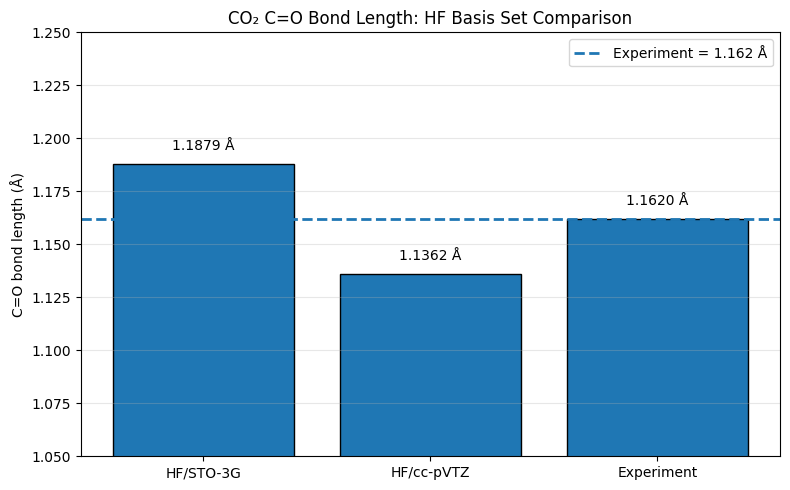

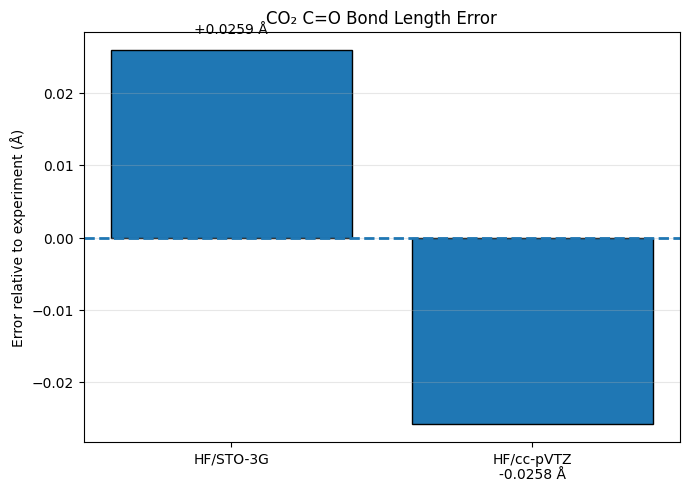

In [3]:
# ------------------------------------------------------------------
# Exercise: HF/STO-3G vs HF/cc-pVTZ bond length for CO2
# ------------------------------------------------------------------
# Goal:
# Compare optimized C=O bond lengths from two basis sets:
#   1. HF/STO-3G
#   2. HF/cc-pVTZ
#
# Experimental C=O bond length for CO2: 1.162 Å
#
# HF = Hartree-Fock.
# Basis set = collection of functions used to build molecular orbitals.
# Geometry optimization = moving atoms until the molecular energy is minimized.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyscf import gto, scf
from pyscf.geomopt.geometric_solver import optimize


# ------------------------------------------------------------------
# Starting CO2 geometry
# ------------------------------------------------------------------
# CO2 is linear:
#
#       O = C = O
#
# We place carbon at the origin.
# One oxygen is at +1.162 Å on the z-axis.
# The other oxygen is at -1.162 Å on the z-axis.
#
# This starts from the experimental bond length.

co2_geometry = """
C  0.000000  0.000000   0.000000
O  0.000000  0.000000   1.162000
O  0.000000  0.000000  -1.162000
"""

experimental_CO = 1.162   # Å

basis_sets = ["STO-3G", "cc-pVTZ"]

results = []


# ------------------------------------------------------------------
# Run geometry optimization for each basis set
# ------------------------------------------------------------------

for basis in basis_sets:
    print("=" * 70)
    print(f"Running HF/{basis} geometry optimization for CO2")
    print("=" * 70)

    # Build molecule
    mol = gto.Mole()
    mol.atom = co2_geometry
    mol.basis = basis
    mol.charge = 0
    mol.spin = 0          # CO2 is closed-shell singlet
    mol.unit = "Angstrom"
    mol.verbose = 0
    mol.build()

    # RHF = Restricted Hartree-Fock
    # Restricted means paired alpha/beta electrons share the same spatial orbitals.
    mf = scf.RHF(mol)
    mf.verbose = 0

    # Optimize geometry
    # This returns a new molecule object with optimized atom positions.
    mol_opt = optimize(mf, maxsteps=100)

    # Get optimized coordinates in Angstrom
    coords = mol_opt.atom_coords(unit="Angstrom")

    # Atom order:
    # 0 = C
    # 1 = O
    # 2 = O
    C_coord = coords[0]
    O1_coord = coords[1]
    O2_coord = coords[2]

    # Compute C=O distances
    # np.linalg.norm(vector) gives the length of a vector.
    CO_1 = np.linalg.norm(O1_coord - C_coord)
    CO_2 = np.linalg.norm(O2_coord - C_coord)

    # Average the two C=O bond lengths
    # They should be almost identical because CO2 is symmetric.
    CO_avg = (CO_1 + CO_2) / 2

    # Final HF energy at optimized geometry
    final_energy = scf.RHF(mol_opt).run(verbose=0).e_tot

    # Error relative to experiment
    error = CO_avg - experimental_CO
    percent_error = 100 * error / experimental_CO

    results.append({
        "Method": f"HF/{basis}",
        "Basis Set": basis,
        "C=O 1 (Å)": CO_1,
        "C=O 2 (Å)": CO_2,
        "Average C=O (Å)": CO_avg,
        "Experimental (Å)": experimental_CO,
        "Error (Å)": error,
        "Percent Error (%)": percent_error,
        "Energy (Ha)": final_energy,
        "N_basis": mol_opt.nao_nr()
    })

    print(f"Optimized C=O bond 1: {CO_1:.6f} Å")
    print(f"Optimized C=O bond 2: {CO_2:.6f} Å")
    print(f"Average C=O bond:     {CO_avg:.6f} Å")
    print(f"Experimental C=O:     {experimental_CO:.6f} Å")
    print(f"Error:                {error:+.6f} Å")
    print(f"Percent error:        {percent_error:+.3f}%")
    print(f"Final HF energy:      {final_energy:.8f} Ha")
    print(f"Number of basis funcs:{mol_opt.nao_nr()}")
    print()


# ------------------------------------------------------------------
# Make results table
# ------------------------------------------------------------------

df = pd.DataFrame(results)

print("\n" + "=" * 90)
print("Summary table")
print("=" * 90)
print(df.to_string(index=False))


# ------------------------------------------------------------------
# Visualization: compare optimized bond lengths with experiment
# ------------------------------------------------------------------

plot_labels = list(df["Method"]) + ["Experiment"]
bond_lengths = list(df["Average C=O (Å)"]) + [experimental_CO]

plt.figure(figsize=(8, 5))

bars = plt.bar(plot_labels, bond_lengths, edgecolor="black")

plt.axhline(
    experimental_CO,
    linestyle="--",
    linewidth=2,
    label=f"Experiment = {experimental_CO:.3f} Å"
)

plt.ylabel("C=O bond length (Å)")
plt.title("CO₂ C=O Bond Length: HF Basis Set Comparison")
plt.ylim(1.05, 1.25)
plt.grid(axis="y", alpha=0.3)
plt.legend()

# Add value labels above bars
for bar, length in zip(bars, bond_lengths):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{length:.4f} Å",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Visualization: errors relative to experiment
# ------------------------------------------------------------------

plt.figure(figsize=(7, 5))

errors = list(df["Error (Å)"])

bars = plt.bar(df["Method"], errors, edgecolor="black")

plt.axhline(0, linestyle="--", linewidth=2)
plt.ylabel("Error relative to experiment (Å)")
plt.title("CO₂ C=O Bond Length Error")
plt.grid(axis="y", alpha=0.3)

for bar, error in zip(bars, errors):
    label_position = error + 0.002 if error >= 0 else error - 0.006
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        label_position,
        f"{error:+.4f} Å",
        ha="center",
        va="bottom" if error >= 0 else "top",
        fontsize=10
    )

plt.tight_layout()
plt.show()

The HF/STO-3G optimization predicted a C=O bond length of 1.1879 Å, which is 0.0259 Å longer than the experimental value of 1.162 Å. The HF/cc-pVTZ optimization predicted a C=O bond length of 1.1362 Å, which is 0.0258 Å shorter than experiment. Although cc-pVTZ is a much larger and more flexible basis set, it does not necessarily give a bond length closer to experiment because it only improves the basis-set description within Hartree-Fock. The remaining error is due to the Hartree-Fock approximation itself, especially the neglect of electron correlation. STO-3G appears similar in error magnitude here because basis-set error and HF method error partly cancel.

Running CO2 RHF/sto-3g
N_basis = 15
Energy  = -185.0652201199 Ha
HOMO    = -10.7080 eV
LUMO    = 8.9352 eV
Gap     = 19.6432 eV

Running CO2 RHF/3-21g
N_basis = 27
Energy  = -186.5610884536 Ha
HOMO    = -14.1815 eV
LUMO    = 5.6043 eV
Gap     = 19.7858 eV

Running CO2 RHF/6-31g
N_basis = 27
Energy  = -187.5149488037 Ha
HOMO    = -14.6275 eV
LUMO    = 4.8997 eV
Gap     = 19.5272 eV

Running CO2 RHF/6-31g*
N_basis = 42
Energy  = -187.6318655216 Ha
HOMO    = -14.6577 eV
LUMO    = 5.8588 eV
Gap     = 20.5165 eV

Running CO2 RHF/6-31+g*
N_basis = 54
Energy  = -187.6366307929 Ha
HOMO    = -14.8658 eV
LUMO    = 1.5355 eV
Gap     = 16.4013 eV

Running CO2 RHF/cc-pvdz
N_basis = 42
Energy  = -187.6507306380 Ha
HOMO    = -14.5898 eV
LUMO    = 5.8720 eV
Gap     = 20.4618 eV

Running CO2 RHF/aug-cc-pvdz
N_basis = 69
Energy  = -187.6624759331 Ha
HOMO    = -14.8205 eV
LUMO    = 1.4923 eV
Gap     = 16.3128 eV

Running CO2 RHF/cc-pvtz
N_basis = 90
Energy  = -187.7068061503 Ha
HOMO    = -14.7581 eV
LUMO

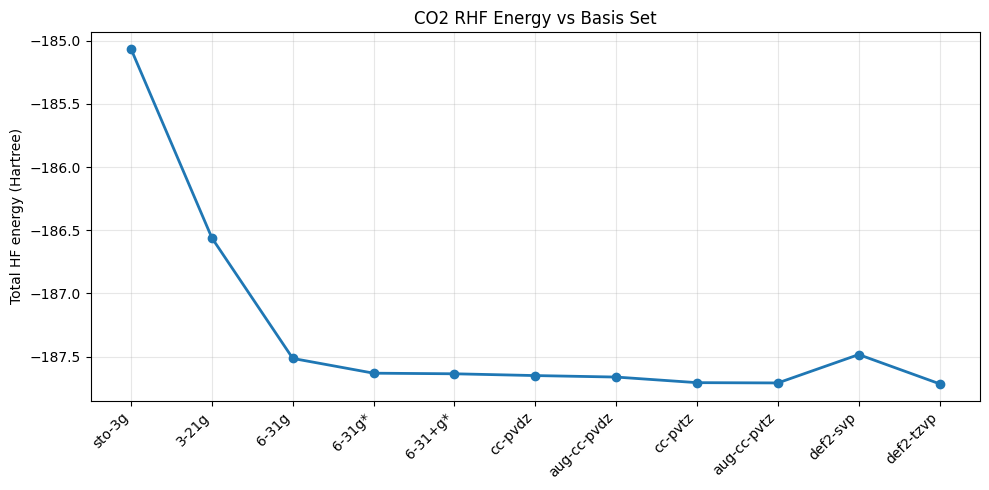

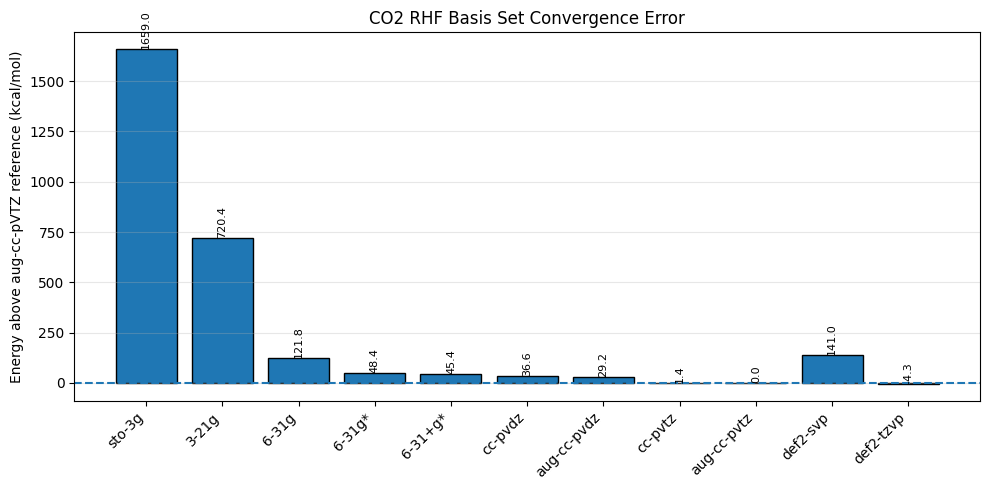

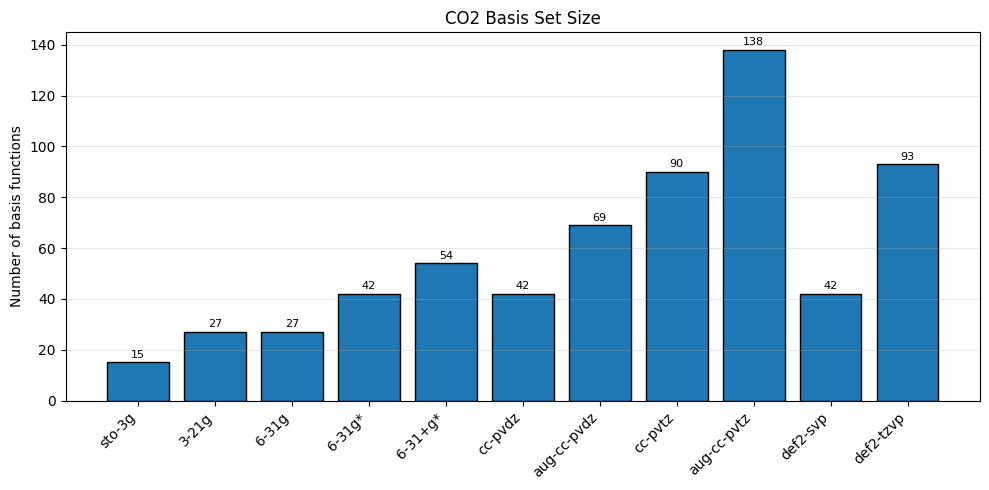

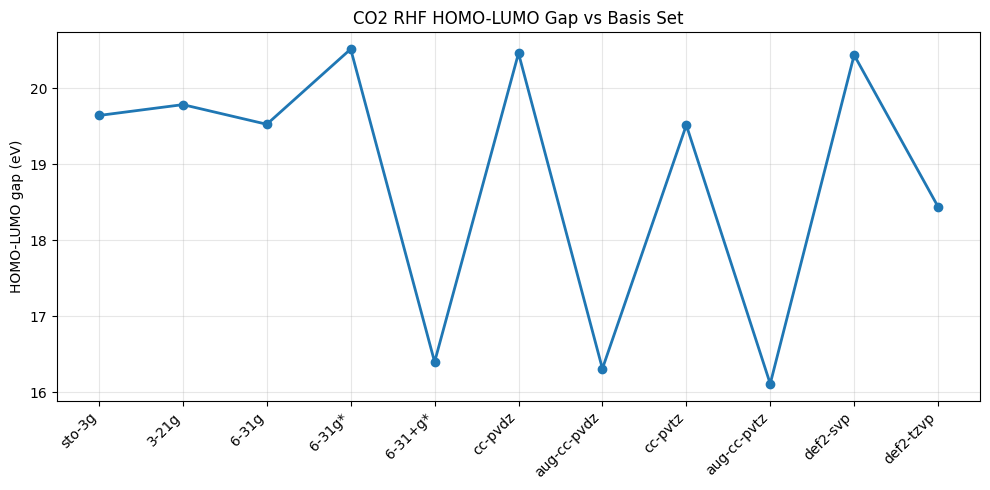

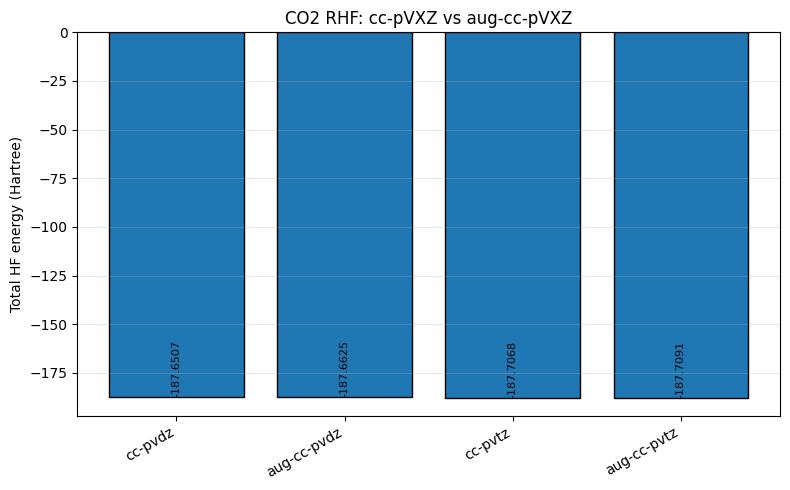


Direct cc vs aug comparison
aug-cc-pVDZ - cc-pVDZ = -0.01174530 Ha
                         -7.3703 kcal/mol
aug-cc-pVTZ - cc-pVTZ = -0.00225278 Ha
                         -1.4136 kcal/mol


In [4]:
# ------------------------------------------------------------------
# Exercise 2: CO2 HF basis set convergence
# ------------------------------------------------------------------
# Compare popular basis sets, including cc-pVDZ/cc-pVTZ
# and aug-cc-pVDZ/aug-cc-pVTZ.
#
# This uses fixed experimental CO2 geometry:
# O=C=O with C=O = 1.162 Å
# ------------------------------------------------------------------

from pyscf import gto, scf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# fixed CO2 geometry
co2_geom = """
C  0.000000  0.000000   0.000000
O  0.000000  0.000000   1.162000
O  0.000000  0.000000  -1.162000
"""

# popular basis sets to compare
basis_sets = [
    "sto-3g",
    "3-21g",
    "6-31g",
    "6-31g*",
    "6-31+g*",
    "cc-pvdz",
    "aug-cc-pvdz",
    "cc-pvtz",
    "aug-cc-pvtz",
    "def2-svp",
    "def2-tzvp"
]

results = []

for basis in basis_sets:
    print("=" * 70)
    print(f"Running CO2 RHF/{basis}")
    print("=" * 70)

    try:
        mol = gto.Mole()
        mol.atom = co2_geom
        mol.basis = basis
        mol.charge = 0
        mol.spin = 0
        mol.unit = "Angstrom"
        mol.verbose = 0
        mol.build()

        mf = scf.RHF(mol)
        mf.verbose = 0
        energy = mf.kernel()

        mo_energies = mf.mo_energy
        mo_occ = mf.mo_occ

        homo_idx = np.where(mo_occ > 0)[0][-1]
        lumo_idx = homo_idx + 1

        homo_ev = mo_energies[homo_idx] * 27.2114
        lumo_ev = mo_energies[lumo_idx] * 27.2114
        gap_ev = lumo_ev - homo_ev

        results.append({
            "Basis": basis,
            "N_basis": mol.nao_nr(),
            "Energy_Ha": energy,
            "Energy_eV": energy * 27.2114,
            "HOMO_eV": homo_ev,
            "LUMO_eV": lumo_ev,
            "Gap_eV": gap_ev
        })

        print(f"N_basis = {mol.nao_nr()}")
        print(f"Energy  = {energy:.10f} Ha")
        print(f"HOMO    = {homo_ev:.4f} eV")
        print(f"LUMO    = {lumo_ev:.4f} eV")
        print(f"Gap     = {gap_ev:.4f} eV")
        print()

    except Exception as err:
        print(f"FAILED for basis {basis}")
        print("Error:", err)
        print()


# ------------------------------------------------------------------
# Make table
# ------------------------------------------------------------------

df = pd.DataFrame(results)

# use aug-cc-pVTZ as reference if it exists
reference_basis = "aug-cc-pvtz"

if reference_basis in list(df["Basis"]):
    reference_energy = df.loc[df["Basis"] == reference_basis, "Energy_Ha"].values[0]
else:
    reference_energy = df["Energy_Ha"].min()

df["Delta_E_Ha"] = df["Energy_Ha"] - reference_energy
df["Delta_E_kcalmol"] = df["Delta_E_Ha"] * 627.509

print("\n" + "=" * 110)
print("CO2 RHF basis set convergence table")
print("=" * 110)

print(
    df[[
        "Basis",
        "N_basis",
        "Energy_Ha",
        "Delta_E_Ha",
        "Delta_E_kcalmol",
        "HOMO_eV",
        "LUMO_eV",
        "Gap_eV"
    ]].to_string(index=False)
)


# ------------------------------------------------------------------
# Plot 1: Total HF energy vs basis set
# ------------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df["Basis"],
    df["Energy_Ha"],
    marker="o",
    linewidth=2
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Total HF energy (Hartree)")
plt.title("CO2 RHF Energy vs Basis Set")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Plot 2: Energy difference from aug-cc-pVTZ
# ------------------------------------------------------------------

plt.figure(figsize=(10, 5))

bars = plt.bar(
    df["Basis"],
    df["Delta_E_kcalmol"],
    edgecolor="black"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Energy above aug-cc-pVTZ reference (kcal/mol)")
plt.title("CO2 RHF Basis Set Convergence Error")
plt.axhline(0, linestyle="--", linewidth=1.5)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, df["Delta_E_kcalmol"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Plot 3: Number of basis functions
# ------------------------------------------------------------------

plt.figure(figsize=(10, 5))

bars = plt.bar(
    df["Basis"],
    df["N_basis"],
    edgecolor="black"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of basis functions")
plt.title("CO2 Basis Set Size")
plt.grid(axis="y", alpha=0.3)

for bar, n in zip(bars, df["N_basis"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(n),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Plot 4: HOMO-LUMO gap
# ------------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df["Basis"],
    df["Gap_eV"],
    marker="o",
    linewidth=2
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("HOMO-LUMO gap (eV)")
plt.title("CO2 RHF HOMO-LUMO Gap vs Basis Set")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Plot 5: cc-pVXZ vs aug-cc-pVXZ only
# ------------------------------------------------------------------

cc_df = df[df["Basis"].isin([
    "cc-pvdz",
    "aug-cc-pvdz",
    "cc-pvtz",
    "aug-cc-pvtz"
])].copy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    cc_df["Basis"],
    cc_df["Energy_Ha"],
    edgecolor="black"
)

plt.ylabel("Total HF energy (Hartree)")
plt.title("CO2 RHF: cc-pVXZ vs aug-cc-pVXZ")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, cc_df["Energy_Ha"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Direct comparison: cc vs aug
# ------------------------------------------------------------------

def get_energy(basis):
    return df.loc[df["Basis"] == basis, "Energy_Ha"].values[0]

print("\n" + "=" * 70)
print("Direct cc vs aug comparison")
print("=" * 70)

if "cc-pvdz" in list(df["Basis"]) and "aug-cc-pvdz" in list(df["Basis"]):
    diff_dz = get_energy("aug-cc-pvdz") - get_energy("cc-pvdz")
    print(f"aug-cc-pVDZ - cc-pVDZ = {diff_dz:.8f} Ha")
    print(f"                         {diff_dz * 627.509:.4f} kcal/mol")

if "cc-pvtz" in list(df["Basis"]) and "aug-cc-pvtz" in list(df["Basis"]):
    diff_tz = get_energy("aug-cc-pvtz") - get_energy("cc-pvtz")
    print(f"aug-cc-pVTZ - cc-pVTZ = {diff_tz:.8f} Ha")
    print(f"                         {diff_tz * 627.509:.4f} kcal/mol")

In [5]:
import pandas as pd

basis_guide = [
    {
        "Basis set": "STO-3G",
        "Type": "Minimal",
        "Best use": "Debugging, code tests, very fast demos",
        "Advantages": "Very fast; simple; good for checking workflow",
        "Disadvantages": "Very inaccurate; poor geometries and energies",
        "Use for final results?": "No"
    },
    {
        "Basis set": "3-21G",
        "Type": "Small split-valence",
        "Best use": "Quick teaching demos and rough trends",
        "Advantages": "Fast; better than STO-3G",
        "Disadvantages": "No polarization; still too crude for real chemistry",
        "Use for final results?": "No"
    },
    {
        "Basis set": "6-31G",
        "Type": "Split-valence",
        "Best use": "Basic comparisons on neutral organic molecules",
        "Advantages": "Common; fast; better valence flexibility",
        "Disadvantages": "No polarization; weak for geometries and properties",
        "Use for final results?": "Usually no"
    },
    {
        "Basis set": "6-31G*",
        "Type": "Polarized split-valence",
        "Best use": "Cheap neutral organic geometries",
        "Advantages": "Adds polarization; much better than 6-31G",
        "Disadvantages": "No diffuse functions; not systematic",
        "Use for final results?": "Sometimes for rough geometry"
    },
    {
        "Basis set": "6-31+G*",
        "Type": "Diffuse + polarized split-valence",
        "Best use": "Anions, lone pairs, weak interactions, virtual orbitals",
        "Advantages": "Diffuse functions help spread-out density",
        "Disadvantages": "More expensive; can cause SCF convergence issues",
        "Use for final results?": "Useful for specific cases"
    },
    {
        "Basis set": "cc-pVDZ",
        "Type": "Correlation-consistent double-zeta",
        "Best use": "Systematic small-molecule calculations",
        "Advantages": "Polarized; systematic; good convergence studies",
        "Disadvantages": "Still double-zeta; no diffuse functions",
        "Use for final results?": "Good starting point"
    },
    {
        "Basis set": "aug-cc-pVDZ",
        "Type": "Diffuse correlation-consistent double-zeta",
        "Best use": "Anions, excited states, weak interactions",
        "Advantages": "Adds diffuse functions; better virtual orbitals",
        "Disadvantages": "More expensive than cc-pVDZ",
        "Use for final results?": "Good when diffuse functions matter"
    },
    {
        "Basis set": "cc-pVTZ",
        "Type": "Correlation-consistent triple-zeta",
        "Best use": "Higher-quality small-molecule energies/geometries",
        "Advantages": "Closer to basis-set limit; systematic",
        "Disadvantages": "More expensive; no diffuse functions",
        "Use for final results?": "Yes for many small molecules"
    },
    {
        "Basis set": "aug-cc-pVTZ",
        "Type": "Diffuse correlation-consistent triple-zeta",
        "Best use": "High-quality anions, excited states, weak interactions",
        "Advantages": "Strong basis; diffuse + polarized + triple-zeta",
        "Disadvantages": "Expensive; may be overkill",
        "Use for final results?": "Yes when needed"
    },
    {
        "Basis set": "def2-SVP",
        "Type": "Practical split-valence polarized",
        "Best use": "Routine DFT geometry optimization",
        "Advantages": "Efficient; broad periodic-table coverage",
        "Disadvantages": "Not a strict convergence ladder",
        "Use for final results?": "Good for geometry"
    },
    {
        "Basis set": "def2-TZVP",
        "Type": "Practical triple-zeta polarized",
        "Best use": "Routine DFT single-point energies",
        "Advantages": "Strong general-purpose basis; practical",
        "Disadvantages": "May need diffuse version for anions/weak interactions",
        "Use for final results?": "Yes for routine DFT"
    }
]

df_basis_guide = pd.DataFrame(basis_guide)

df_basis_guide

,Basis set,Type,Best use,Advantages,Disadvantages,Use for final results?
0,STO-3G,Minimal,"Debugging, code tests, very fast demos",Very fast; simple; good for checking workflow,Very inaccurate; poor geometries and energies,No
1,3-21G,Small split-valence,Quick teaching demos and rough trends,Fast; better than STO-3G,No polarization; still too crude for real chem...,No
2,6-31G,Split-valence,Basic comparisons on neutral organic molecules,Common; fast; better valence flexibility,No polarization; weak for geometries and prope...,Usually no
3,6-31G*,Polarized split-valence,Cheap neutral organic geometries,Adds polarization; much better than 6-31G,No diffuse functions; not systematic,Sometimes for rough geometry
4,6-31+G*,Diffuse + polarized split-valence,"Anions, lone pairs, weak interactions, virtual...",Diffuse functions help spread-out density,More expensive; can cause SCF convergence issues,Useful for specific cases
5,cc-pVDZ,Correlation-consistent double-zeta,Systematic small-molecule calculations,Polarized; systematic; good convergence studies,Still double-zeta; no diffuse functions,Good starting point
6,aug-cc-pVDZ,Diffuse correlation-consistent double-zeta,"Anions, excited states, weak interactions",Adds diffuse functions; better virtual orbitals,More expensive than cc-pVDZ,Good when diffuse functions matter
7,cc-pVTZ,Correlation-consistent triple-zeta,Higher-quality small-molecule energies/geometries,Closer to basis-set limit; systematic,More expensive; no diffuse functions,Yes for many small molecules
8,aug-cc-pVTZ,Diffuse correlation-consistent triple-zeta,"High-quality anions, excited states, weak inte...",Strong basis; diffuse + polarized + triple-zeta,Expensive; may be overkill,Yes when needed
9,def2-SVP,Practical split-valence polarized,Routine DFT geometry optimization,Efficient; broad periodic-table coverage,Not a strict convergence ladder,Good for geometry


The CO₂ RHF basis-set convergence results show that the total hf energy becomes much more negative as the basis set improves. This is expected from the variational principle. The largest energy improvements occur when going from very small basis sets like STO-3G and 3-21G to more flexible split-valence and polarized basis sets like 6-31G, 6-31G*, and cc-pVDZ.

The convergence becomes much slower once the basis set is already reasonably large. For example, going from cc-pVDZ to cc-pVTZ lowers the energy a lot more than adding diffuse functions to cc-pVTZ. This flattening is the main sign of basis-set convergence: each extra improvement in the basis set gives a smaller change in energy. In this calculation, cc-pVTZ and aug-cc-pVTZ are very close, with aug-cc-pVTZ only lower by about 1.41 kcal/mol. This means that diffuse functions still help, but their effect is smaller at the triple-zeta level.

The augmented basis sets show the effect of diffuse functions. The aug- prefix adds wide, spread-out functions that describe electron density far from the nuclei. For CO₂, adding diffuse functions to cc-pVDZ lowers the energy by about 7.37 kcal/mol, while adding diffuse functions to cc-pVTZ lowers it by only about 1.41 kcal/mol. So diffuse functions matter more when the base basis set is still incomplete. They are especially important for anions, excited states, weak interactions, and cases where the electron density is spread out.

The HOMO-LUMO gap changes a lot when diffuse functions are added. This happens because diffuse functions strongly affect virtual orbitals such as the LUMO. The occupied orbitals are usually more compact and closer to the nuclei, while virtual orbitals can be more spatially spread out. Because the LUMO is lowered by diffuse functions, the HOMO-LUMO gap becomes smaller for 6-31+G*, aug-cc-pVDZ, and aug-cc-pVTZ. This is useful for seeing trends, but HF HOMO-LUMO gaps should not be treated as accurate experimental excitation energies.

The def2 basis sets behave differently from the cc-pVXZ basis sets because they were designed for practical general-purpose calculations, not as a strict correlation-consistent convergence ladder. In this CO₂ HF calculation, def2-SVP is not as low in energy as cc-pVDZ, while def2-TZVP gives an even lower energy than aug-cc-pVTZ. That does not mean def2-TZVP is always “better”; it means the basis sets are built differently. For this exercise, the cleanest systematic comparison is the Dunning sequence: cc-pVDZ, aug-cc-pVDZ, cc-pVTZ, and aug-cc-pVTZ.

 the main lesson is that basis-set improvement and chemical accuracy are related but not identical. Larger basis sets improve the HF calculation by reducing basis-set error, but they do not fix the Hartree–Fock approximation itself. HF still lacks electron correlation, so even a very large basis set gives the best HF answer, not the exact experimental answer.

In [7]:
# ------------------------------------------------------------------
# ECP exercise: Cu vs Fe using def2-SVP in PySCF
# ------------------------------------------------------------------
# Fe has 26 electrons, so neutral Fe can be built with spin = 0 here.
# Cu has 29 electrons, so neutral Cu needs spin = 1.
#
# PySCF uses:
#     mol.spin = N_alpha - N_beta = 2S
#
# For Cu:
#     29 electrons means odd electron count
#     so spin = 1 is needed.

from pyscf import gto
import pandas as pd


def build_atom(symbol, Z, spin, use_ecp=True):
    mol = gto.Mole()
    mol.atom = f"{symbol} 0 0 0"
    mol.basis = "def2-SVP"

    if use_ecp:
        mol.ecp = "def2-SVP"

    mol.charge = 0
    mol.spin = spin
    mol.verbose = 0
    mol.build()

    return mol


atoms = [
    # symbol, atomic number, spin
    ("Fe", 26, 0),
    ("Cu", 29, 1)
]

results = []

for symbol, Z, spin in atoms:
    print("=" * 70)
    print(f"Testing {symbol} with def2-SVP and requested def2-SVP ECP")
    print("=" * 70)

    mol_ecp = build_atom(symbol, Z, spin, use_ecp=True)
    mol_ae = build_atom(symbol, Z, spin, use_ecp=False)

    core_replaced = mol_ecp.atom_nelec_core(0)

    results.append({
        "Element": symbol,
        "Z": Z,
        "spin": spin,
        "Requested ECP": "def2-SVP",
        "Core electrons replaced": core_replaced,
        "Electrons treated with ECP request": mol_ecp.nelectron,
        "All-electron count": mol_ae.nelectron,
        "Basis functions with ECP request": mol_ecp.nao_nr(),
        "All-electron basis functions": mol_ae.nao_nr()
    })

    print(f"Element:                          {symbol} (Z = {Z})")
    print(f"PySCF spin:                       {spin}")
    print(f"Requested ECP:                    def2-SVP")
    print(f"Core electrons replaced by ECP:   {core_replaced}")
    print(f"Electrons treated explicitly:     {mol_ecp.nelectron}")
    print(f"All-electron count:               {mol_ae.nelectron}")
    print(f"Basis functions with ECP request: {mol_ecp.nao_nr()}")
    print(f"All-electron basis functions:     {mol_ae.nao_nr()}")

    if core_replaced == 0:
        print(f"\nConclusion for {symbol}: No ECP was actually applied.")
        print(f"{symbol}/def2-SVP is being treated as all-electron in this PySCF setup.")
    else:
        print(f"\nConclusion for {symbol}: ECP was applied.")
        print(f"{core_replaced} core electrons were replaced.")
        print(f"{mol_ecp.nelectron} electrons are treated explicitly.")

    print()


df = pd.DataFrame(results)

print("=" * 110)
print("Summary table")
print("=" * 110)
print(df.to_string(index=False))

Testing Fe with def2-SVP and requested def2-SVP ECP
Element:                          Fe (Z = 26)
PySCF spin:                       0
Requested ECP:                    def2-SVP
Core electrons replaced by ECP:   0
Electrons treated explicitly:     26
All-electron count:               26
Basis functions with ECP request: 31
All-electron basis functions:     31

Conclusion for Fe: No ECP was actually applied.
Fe/def2-SVP is being treated as all-electron in this PySCF setup.

Testing Cu with def2-SVP and requested def2-SVP ECP
Element:                          Cu (Z = 29)
PySCF spin:                       1
Requested ECP:                    def2-SVP
Core electrons replaced by ECP:   0
Electrons treated explicitly:     29
All-electron count:               29
Basis functions with ECP request: 31
All-electron basis functions:     31

Conclusion for Cu: No ECP was actually applied.
Cu/def2-SVP is being treated as all-electron in this PySCF setup.

Summary table
Element  Z  spin Requested ECP  

ECP def2-SVP not found for  Fe
ECP def2-SVP not found for  Cu


I created PySCF Mole objects for Fe and Cu using def2-SVP and requested def2-SVP ECPs. For Fe, PySCF reported that 0 core electrons were replaced, so all 26 electrons were treated explicitly. For Cu, after setting the correct spin value of mol.spin = 1 for neutral Cu, PySCF also reported that 0 core electrons were replaced, so all 29 electrons were treated explicitly. Therefore, in this PySCF setup, requesting def2-SVP ECP for Fe or Cu does not actually apply an ECP. Both Fe and Cu are treated as all-electron def2-SVP calculations. The warning messages ECP def2-SVP not found for Fe and ECP def2-SVP not found for Cu confirm that PySCF could not find matching ECPs for these elements.

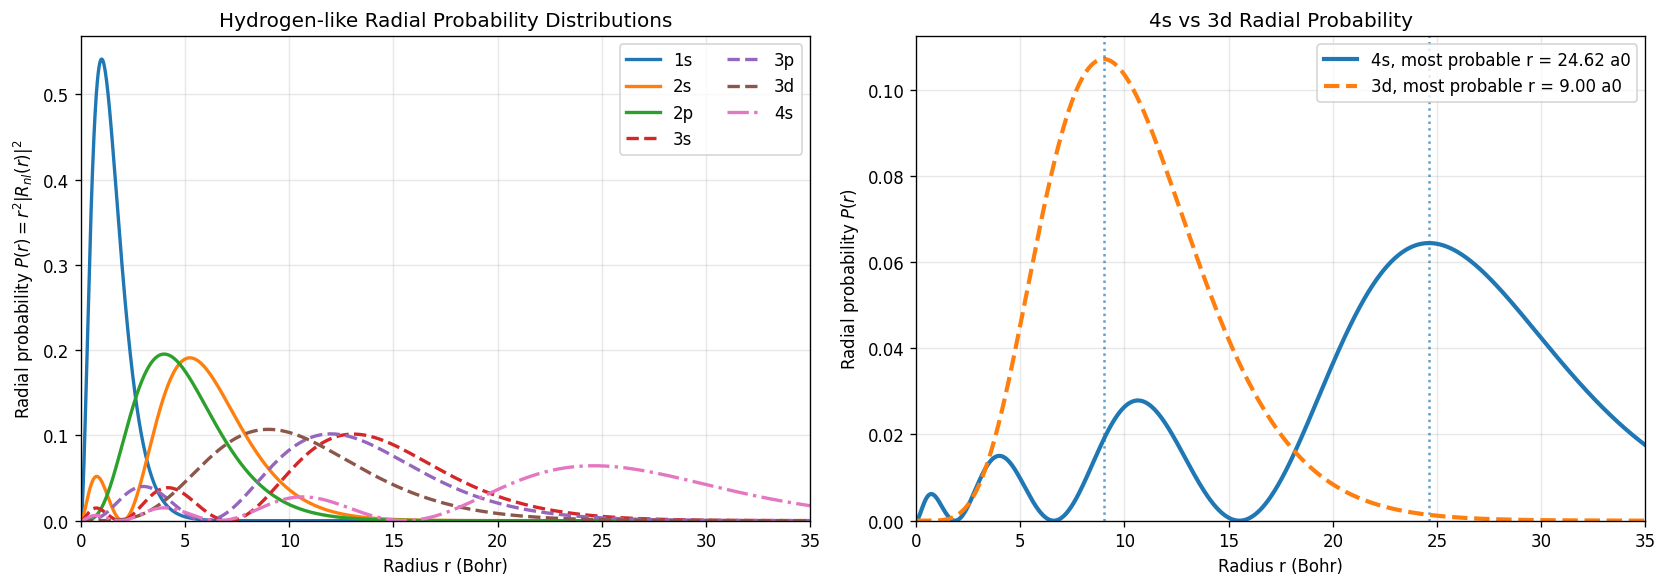

Most probable radii and radial nodes
1s    n = 1   l = 0   radial nodes = 0   r_mp = 1.002 a0
2s    n = 2   l = 0   radial nodes = 1   r_mp = 5.233 a0
2p    n = 2   l = 1   radial nodes = 0   r_mp = 3.996 a0
3s    n = 3   l = 0   radial nodes = 2   r_mp = 13.076 a0
3p    n = 3   l = 1   radial nodes = 1   r_mp = 11.996 a0
3d    n = 3   l = 2   radial nodes = 0   r_mp = 9.003 a0
4s    n = 4   l = 0   radial nodes = 3   r_mp = 24.622 a0

1 Bohr = 0.529 Å

Key point:
4s has l = 0, so it penetrates closer to the nucleus.
3d has l = 2, so it is less penetrating and is more shielded.
In transition metals, 4s and 3d become close in energy because
penetration, shielding, and electron-electron repulsion compete.


In [8]:
# ------------------------------------------------------------------
# Radial Probability Distributions: add 4s and 3d orbitals
# ------------------------------------------------------------------
# P(r) = r^2 |R_nl(r)|^2
#
# This is still a hydrogen-like model.
# It is useful for seeing radial shape, nodes, and penetration.
#
# n = principal quantum number
# l = angular momentum quantum number
#
# s orbital: l = 0
# p orbital: l = 1
# d orbital: l = 2

import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import factorial, genlaguerre


def hydrogen_radial(n, l, r, Z=1):
    """
    Normalized radial wavefunction R_nl(r) for a hydrogen-like atom.

    n: principal quantum number
    l: angular momentum quantum number
    r: radius in Bohr
    Z: nuclear charge; Z=1 for hydrogen
    """

    rho = 2 * Z * r / n

    # Normalization constant for hydrogen-like radial functions
    norm = np.sqrt(
        (2 * Z / n)**3
        * factorial(n - l - 1)
        / (2 * n * factorial(n + l))
    )

    # Associated Laguerre polynomial
    L = genlaguerre(n - l - 1, 2 * l + 1)(rho)

    return norm * np.exp(-rho / 2) * rho**l * L


# radius grid in Bohr radii
r = np.linspace(0.001, 45, 4000)

orbitals = [
    (1, 0, "1s", "solid"),
    (2, 0, "2s", "solid"),
    (2, 1, "2p", "solid"),
    (3, 0, "3s", "dashed"),
    (3, 1, "3p", "dashed"),
    (3, 2, "3d", "dashed"),
    (4, 0, "4s", "dashdot"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# ------------------------------------------------------------------
# Left plot: all orbitals including 4s and 3d
# ------------------------------------------------------------------

ax = axes[0]

for n, l, label, linestyle in orbitals:
    R = hydrogen_radial(n, l, r)
    P = r**2 * R**2

    ax.plot(
        r,
        P,
        label=f"{label}",
        linestyle=linestyle,
        linewidth=2
    )

ax.set_xlim(0, 35)
ax.set_ylim(bottom=0)
ax.set_xlabel("Radius r (Bohr)")
ax.set_ylabel(r"Radial probability $P(r)=r^2|R_{nl}(r)|^2$")
ax.set_title("Hydrogen-like Radial Probability Distributions")
ax.legend(ncol=2)
ax.grid(True, alpha=0.3)


# ------------------------------------------------------------------
# Right plot: focus on 4s vs 3d
# ------------------------------------------------------------------

ax2 = axes[1]

compare_orbitals = [
    (4, 0, "4s", "solid"),
    (3, 2, "3d", "dashed"),
]

for n, l, label, linestyle in compare_orbitals:
    R = hydrogen_radial(n, l, r)
    P = r**2 * R**2

    r_mp = r[np.argmax(P)]

    ax2.plot(
        r,
        P,
        label=f"{label}, most probable r = {r_mp:.2f} a0",
        linestyle=linestyle,
        linewidth=2.5
    )

    ax2.axvline(
        r_mp,
        linestyle=":",
        alpha=0.7
    )

ax2.set_xlim(0, 35)
ax2.set_ylim(bottom=0)
ax2.set_xlabel("Radius r (Bohr)")
ax2.set_ylabel(r"Radial probability $P(r)$")
ax2.set_title("4s vs 3d Radial Probability")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Print most probable radii and number of radial nodes
# ------------------------------------------------------------------

print("=" * 70)
print("Most probable radii and radial nodes")
print("=" * 70)

for n, l, label, linestyle in orbitals:
    R = hydrogen_radial(n, l, r)
    P = r**2 * R**2

    r_mp = r[np.argmax(P)]
    radial_nodes = n - l - 1

    print(f"{label:3s}   n = {n}   l = {l}   radial nodes = {radial_nodes}   r_mp = {r_mp:.3f} a0")

print()
print("1 Bohr = 0.529 Å")
print()
print("Key point:")
print("4s has l = 0, so it penetrates closer to the nucleus.")
print("3d has l = 2, so it is less penetrating and is more shielded.")
print("In transition metals, 4s and 3d become close in energy because")
print("penetration, shielding, and electron-electron repulsion compete.")

The plot shows that the **4s orbital is much more radially extended** than the 3d orbital, but it also has inner peaks near the nucleus. Because 4s has (l=0), it can **penetrate** close to the nucleus and feel a stronger effective nuclear attraction. The 3d orbital has (l=2), so it penetrates less and is more shielded by inner electrons, but it is also more compact and lies closer to the nucleus than the outer part of 4s. In transition metals, these effects compete: 4s is stabilized by penetration, while 3d is stabilized by being compact and less far from the nucleus. As electrons are added, electron-electron repulsion and shielding shift the 4s and 3d energies until they become very close, which is why transition metals fill and ionize in a way where 4s and 3d are strongly coupled.


pseduo code for water dimer


Choose method and basis set
    method = HF, MP2, or DFT
    basis  = cc-pVDZ, aug-cc-pVDZ, def2-SVP, etc.

Define full water dimer geometry
    fragment A = water molecule 1
    fragment B = water molecule 2

Step 1: Compute full dimer energy
    Build molecule AB with all atoms real
    Use full basis on all atoms
    Compute E_AB_AB

Step 2: Compute monomer A energy in its own basis
    Build molecule A only
    Delete fragment B completely
    Use basis only on atoms of A
    Compute E_A_A

Step 3: Compute monomer B energy in its own basis
    Build molecule B only
    Delete fragment A completely
    Use basis only on atoms of B
    Compute E_B_B

Step 4: Compute monomer A energy in the full dimer basis
    Build molecule with:
        atoms of A real
        atoms of B as ghost atoms
    Ghost atoms have:
        no nuclear charge
        no electrons
        basis functions still present
    Compute E_A_AB

Step 5: Compute monomer B energy in the full dimer basis
    Build molecule with:
        atoms of B real
        atoms of A as ghost atoms
    Ghost atoms have:
        no nuclear charge
        no electrons
        basis functions still present
    Compute E_B_AB

Step 6: Compute uncorrected interaction energy
    Delta_E_uncorrected = E_AB_AB - E_A_A - E_B_B

Step 7: Compute counterpoise-corrected interaction energy
    Delta_E_CP = E_AB_AB - E_A_AB - E_B_AB

Step 8: Estimate BSSE
    BSSE = Delta_E_uncorrected - Delta_E_CP

Equivalent:
    BSSE = (E_A_AB - E_A_A) + (E_B_AB - E_B_B)

Step 9: Interpret
    If BSSE is large:
        the basis set is too small for reliable binding energy
    If BSSE is small:
        the basis set is closer to complete-basis behavior

## Basis Set Superposition Error (BSSE) and Counterpoise Correction

Basis set superposition error (BSSE) happens when two molecules are calculated together and each molecule can use basis functions from the other molecule. For the water dimer, water A can “borrow” basis functions from water B, and water B can “borrow” basis functions from water A. This artificially lowers the dimer energy, so the uncorrected binding energy becomes too negative.

The Boys–Bernardi counterpoise correction estimates this error by computing each monomer in the full dimer basis. This is done using ghost atoms. A ghost atom has no nuclear charge and no electrons, but it still provides basis functions.

For the water dimer, define water A and water B as the two monomers.

The uncorrected interaction energy is

$$
\Delta E_{\mathrm{uncorrected}}
=
E_{AB}^{AB}
-
E_A^A
-
E_B^B
$$

where:

- $E_{AB}^{AB}$ is the energy of the full water dimer in the full dimer basis.
- $E_A^A$ is the energy of water monomer A in its own basis.
- $E_B^B$ is the energy of water monomer B in its own basis.

The counterpoise-corrected interaction energy is

$$
\Delta E_{\mathrm{CP}}
=
E_{AB}^{AB}
-
E_A^{AB}
-
E_B^{AB}
$$

where:

- $E_A^{AB}$ is the energy of monomer A computed with water B present only as ghost basis functions.
- $E_B^{AB}$ is the energy of monomer B computed with water A present only as ghost basis functions.

The BSSE estimate is

$$
\mathrm{BSSE}
=
\Delta E_{\mathrm{uncorrected}}
-
\Delta E_{\mathrm{CP}}
$$

Equivalently,

$$
\mathrm{BSSE}
=
(E_A^{AB} - E_A^A)
+
(E_B^{AB} - E_B^B)
$$


I used an LLM to generate this response for the format of the equations


# 02 — Hartree-Fock Theory

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/02_hartree_fock.ipynb)

## 🎯 Learning Objectives

- Hartree-Fock approximation and Slater determinants
- HF calculations on simple molecules with PySCF
- SCF convergence and understand the iterative procedure
- Koopmans' theorem to estimate ionization energies
- Why HF fails for bond dissociation (static correlation)?
- HF vs. perturbation theory (MP2) for H₂ dissociation

## 2. Theory: Hartree-Fock Approximation

### 2.1 The Variational Principle and Slater Determinants

The exact many-electron wavefunction $\Psi(x_1, x_2, \ldots, x_N)$ is approximated
in HF as a single **Slater determinant** of one-electron spin-orbitals $\chi_i$:

$$\Psi_{HF} = \frac{1}{\sqrt{N!}} \begin{vmatrix} \chi_1(x_1) & \chi_2(x_1) & \cdots & \chi_N(x_1) \\ \chi_1(x_2) & \chi_2(x_2) & \cdots & \chi_N(x_2) \\ \vdots & \vdots & \ddots & \vdots \\ \chi_1(x_N) & \chi_2(x_N) & \cdots & \chi_N(x_N) \end{vmatrix}$$

The Slater determinant **automatically satisfies the Pauli antisymmetry principle**.

### 2.2 The Fock Operator and HF Equations

Applying the variational principle to the Slater determinant yields the
**Hartree-Fock equations** (Roothan equations in the LCAO-MO basis):

$$\hat{F} |\phi_i\rangle = \epsilon_i |\phi_i\rangle$$

The Fock operator is:
$$\hat{F} = \hat{h} + \sum_j [2\hat{J}_j - \hat{K}_j]$$

where:
- $\hat{h}$ = one-electron (core) Hamiltonian (kinetic + nuclear attraction)
- $\hat{J}_j$ = Coulomb operator: $\hat{J}_j \phi_i(1) = \left[\int |\phi_j(2)|^2 r_{12}^{-1} d2\right] \phi_i(1)$
- $\hat{K}_j$ = Exchange operator: $\hat{K}_j \phi_i(1) = \left[\int \phi_j^*(2) \phi_i(2) r_{12}^{-1} d2\right] \phi_j(1)$

### 2.3 SCF Procedure

Because $\hat{F}$ depends on $\{\phi_i\}$, the equations are solved iteratively:

1. **Initial guess** for density matrix $\mathbf{P}$
2. **Build** Fock matrix $F_{\mu\nu} = H_{\mu\nu}^{core} + \sum_{\lambda\sigma} P_{\lambda\sigma} [(\mu\nu|\sigma\lambda) - \frac{1}{2}(\mu\lambda|\sigma\nu)]$
3. **Solve** $\mathbf{FC} = \mathbf{SC}\boldsymbol{\epsilon}$ (generalized eigenvalue problem)
4. **Update** density matrix $P_{\mu\nu} = 2\sum_{i}^{occ} C_{\mu i} C_{\nu i}$
5. **Check convergence** — repeat from step 2 if not converged

### 2.4 Koopmans' Theorem

The negative of the HF orbital energy approximates the ionization energy:
$$IE_i \approx -\epsilon_i$$

This is **Koopmans' theorem** — it assumes the other orbitals do not relax upon ionization
(the frozen orbital approximation). It is exact within HF but neglects orbital relaxation
and correlation effects.

### 2.5 What HF misses: Electron Correlation

HF accounts for Coulomb repulsion only *on average* through the mean-field potential.
It completely misses **electron correlation** — the instantaneous correlated motion
of electrons. The correlation energy is defined as:

$$E_{corr} = E_{exact} - E_{HF} < 0$$

**Static correlation** (near-degenerate configurations) and **dynamic correlation**
(short-range electron-electron cusps) both require post-HF methods.

In [8]:
# =============================================================================
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyscf import gto, scf, mp

# ------------------------------------------------------------------
# HF/6-31G* calculations on small molecules
# ------------------------------------------------------------------
molecules = {
    'H2O':  'O 0 0 0; H 0 0.757 -0.469; H 0 -0.757 -0.469',
    'NH3':  'N 0 0 0.116; H 0 0.939 -0.269; H 0.814 -0.469 -0.269; H -0.814 -0.469 -0.269',
    'CO':   'C 0 0 0; O 0 0 1.128',
    'HF':   'H 0 0 0; F 0 0 0.917',
}

results = []
for name, atom_str in molecules.items():
    mol = gto.Mole()
    mol.atom = atom_str
    mol.basis = '6-31g*'
    mol.verbose = 0
    mol.build()
    
    mf = scf.RHF(mol)
    mf.verbose = 0
    e = mf.kernel()
    
    # Dipole moment
    dm = mf.make_rdm1()
    dip = mf.dip_moment(mol, dm, verbose=0)
    dip_mag = np.linalg.norm(dip)
    
    # HOMO/LUMO
    mo_e = mf.mo_energy
    mo_occ = mf.mo_occ
    homo_idx = np.where(mo_occ > 0)[0][-1]
    lumo_idx = homo_idx + 1
    homo_ev = mo_e[homo_idx] * 27.2114
    lumo_ev = mo_e[lumo_idx] * 27.2114
    gap_ev = lumo_ev - homo_ev
    
    results.append({
        'Molecule': name,
        'E_HF (Ha)': round(e, 6),
        'Dipole (D)': round(dip_mag, 3),
        'HOMO (eV)': round(homo_ev, 3),
        'LUMO (eV)': round(lumo_ev, 3),
        'Gap (eV)': round(gap_ev, 3),
    })
    print(f"  {name:5s}  E = {e:.6f} Ha  μ = {dip_mag:.3f} D  HOMO = {homo_ev:.2f} eV")

df = pd.DataFrame(results)
print("\n")
print("HF/6-31G* Results:")
print(df.to_string(index=False))

  H2O    E = -75.999265 Ha  μ = 1.932 D  HOMO = -13.57 eV
  NH3    E = -56.183313 Ha  μ = 1.951 D  HOMO = -11.47 eV
  CO     E = -112.736788 Ha  μ = 0.331 D  HOMO = -14.90 eV
  HF     E = -100.000747 Ha  μ = 1.984 D  HOMO = -17.10 eV


HF/6-31G* Results:
Molecule   E_HF (Ha)  Dipole (D)  HOMO (eV)  LUMO (eV)  Gap (eV)
     H2O  -75.999265       1.932    -13.571      6.293    19.864
     NH3  -56.183313       1.951    -11.471      6.049    17.521
      CO -112.736788       0.331    -14.897      4.409    19.305
      HF -100.000747       1.984    -17.102      5.995    23.097


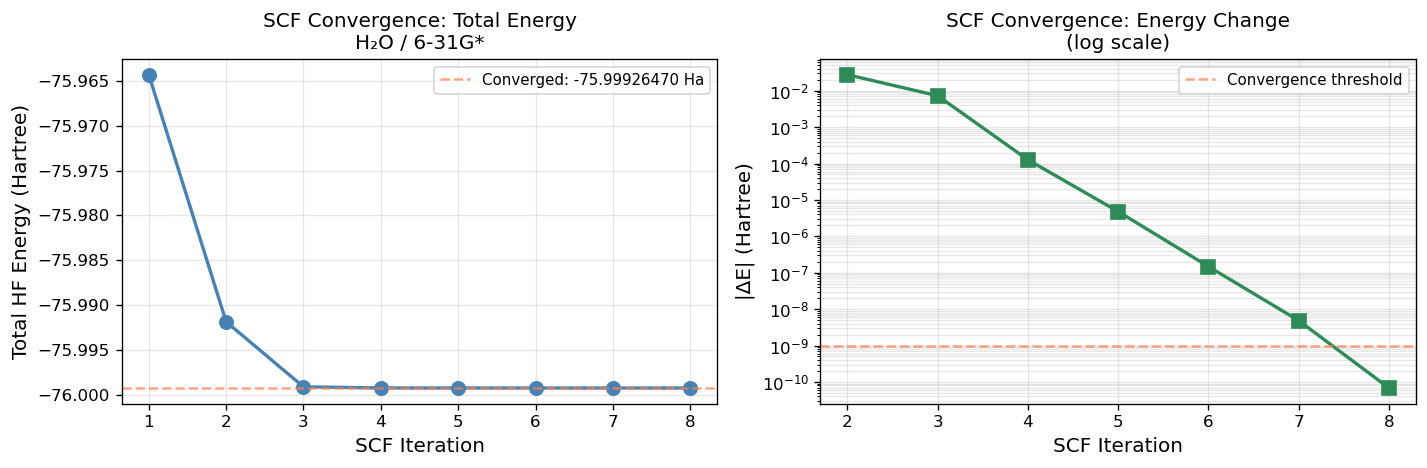


Converged in 8 SCF iterations
Final energy: -75.9992646967 Ha


In [9]:
# ------------------------------------------------------------------
# SCF Convergence Monitoring
# ------------------------------------------------------------------
# PySCF allows us to inject a callback function that is called
# at the end of each SCF iteration.

energies = []
diis_errors = []

def scf_callback(envs):
    """Called after each SCF iteration."""
    energies.append(envs['e_tot'])
    if 'norm_gorb' in envs:
        diis_errors.append(envs['norm_gorb'])

mol = gto.Mole()
mol.atom = 'O 0 0 0; H 0 0.757 -0.469; H 0 -0.757 -0.469'
mol.basis = '6-31g*'
mol.verbose = 0
mol.build()

mf = scf.RHF(mol)
mf.verbose = 0
mf.callback = scf_callback
mf.kernel()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

iterations = list(range(1, len(energies) + 1))

# Panel 1: Total energy vs iteration
ax1.plot(iterations, energies, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.axhline(y=energies[-1], color='coral', linestyle='--', alpha=0.7,
            label=f'Converged: {energies[-1]:.8f} Ha')
ax1.set_xlabel('SCF Iteration', fontsize=12)
ax1.set_ylabel('Total HF Energy (Hartree)', fontsize=12)
ax1.set_title('SCF Convergence: Total Energy\nH₂O / 6-31G*', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: Energy change per iteration (log scale)
energy_changes = [abs(energies[i] - energies[i-1]) for i in range(1, len(energies))]
ax2.semilogy(range(2, len(energies)+1), energy_changes, 's-',
             color='seagreen', linewidth=2, markersize=8)
ax2.axhline(y=1e-9, color='coral', linestyle='--', alpha=0.7, label='Convergence threshold')
ax2.set_xlabel('SCF Iteration', fontsize=12)
ax2.set_ylabel('|ΔE| (Hartree)', fontsize=12)
ax2.set_title('SCF Convergence: Energy Change\n(log scale)', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()
print(f"\nConverged in {len(energies)} SCF iterations")
print(f"Final energy: {energies[-1]:.10f} Ha")

##
**For the below calculations, you can also use ../data/sample_inputs/HF_MP2_SP_H2_diss_ORCA.inp file**

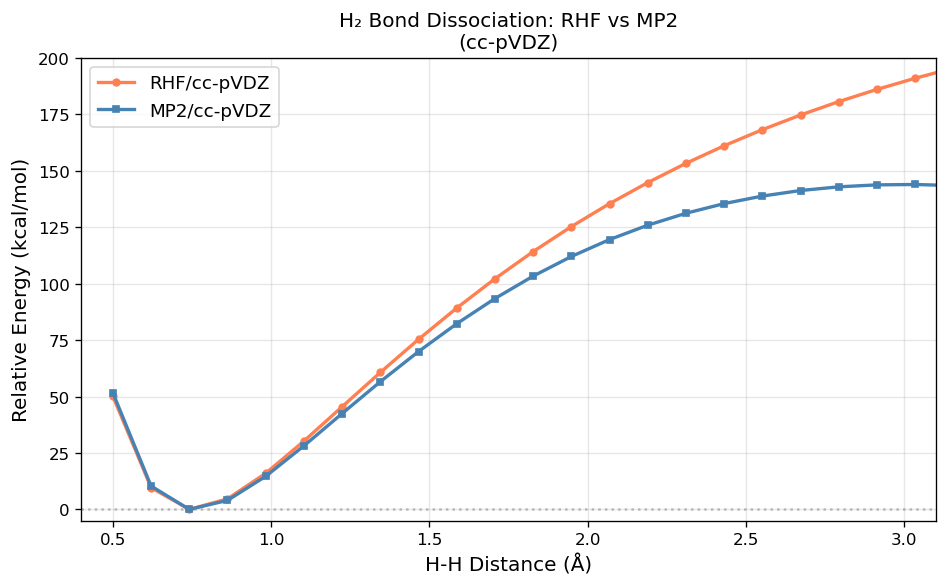

  RHF forces the wavefunction to be a single Slater determinant,
  which cannot properly describe bond breaking.
  At large r(H-H), the true wavefunction should be:
    Ψ ∝ |H↑ H↓⟩ - |H↓ H↑⟩  (purely covalent)
  But RHF gives equal weight to ionic H⁺H⁻ configurations.
CPU times: user 3.91 s, sys: 37.5 ms, total: 3.95 s
Wall time: 1.11 s


In [18]:
%%time
# ------------------------------------------------------------------
# H₂ Bond Dissociation: RHF vs MP2
# ------------------------------------------------------------------
# RHF fails at dissociation because it forces double occupation,
# giving incorrect ionic character (H⁺ + H⁻) at long range.
# MP2 partially corrects this via perturbation theory.

from pyscf import gto, scf, mp

distances = np.linspace(0.5, 4.0, 30)   # Angstroms
e_rhf = []
e_mp2 = []

for d in distances:
    mol = gto.Mole()
    mol.atom = f'H 0 0 0; H 0 0 {d}'
    mol.basis = 'cc-pVDZ'
    mol.verbose = 0
    mol.build()
    
    mf = scf.RHF(mol)
    mf.verbose = 0
    ehf = mf.kernel()
    e_rhf.append(ehf)
    
    # MP2 on top of RHF
    mpt = mp.MP2(mf)
    mpt.verbose = 0
    emp2, _ = mpt.kernel()
    e_mp2.append(ehf + emp2)

e_rhf = np.array(e_rhf)
e_mp2 = np.array(e_mp2)

# Normalize to equilibrium minimum
e_rhf_norm = (e_rhf - e_rhf.min()) * 627.509   # kcal/mol
e_mp2_norm = (e_mp2 - e_mp2.min()) * 627.509

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(distances, e_rhf_norm, 'o-', color='coral', linewidth=2,
        markersize=4, label='RHF/cc-pVDZ')
ax.plot(distances, e_mp2_norm, 's-', color='steelblue', linewidth=2,
        markersize=4, label='MP2/cc-pVDZ')

# Reference: exact 2H dissociation limit
# 2 * E(H atom, UHF) at large distance
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

ax.set_xlabel('H-H Distance (Å)', fontsize=12)
ax.set_ylabel('Relative Energy (kcal/mol)', fontsize=12)
ax.set_title('H₂ Bond Dissociation: RHF vs MP2\n(cc-pVDZ)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.4, 3.1)
ax.set_ylim(-5, 200)

# Annotate RHF error
ax.annotate('RHF unphysically\nraises at dissociation\n(static correlation error)',
            xy=(3.5, e_rhf_norm[-3]), xytext=(2.5, 50),
            arrowprops=dict(arrowstyle='->', color='coral'),
            fontsize=9, color='coral')

plt.tight_layout()
plt.show()

print("  RHF forces the wavefunction to be a single Slater determinant,")
print("  which cannot properly describe bond breaking.")
print("  At large r(H-H), the true wavefunction should be:")
print("    Ψ ∝ |H↑ H↓⟩ - |H↓ H↑⟩  (purely covalent)")
print("  But RHF gives equal weight to ionic H⁺H⁻ configurations.")

Koopmans' Theorem: HF/6-31G* Ionization Energies
Molecule  Computed IE (eV)  Experimental IE (eV)  Error (eV)
     H2O             13.57                 12.62        0.95
     NH3             11.47                 10.07        1.40
      CO             14.90                 14.01        0.89
      HF             17.10                 16.03        1.07
      N2             16.63                 15.58        1.05

Mean Absolute Error: 1.07 eV


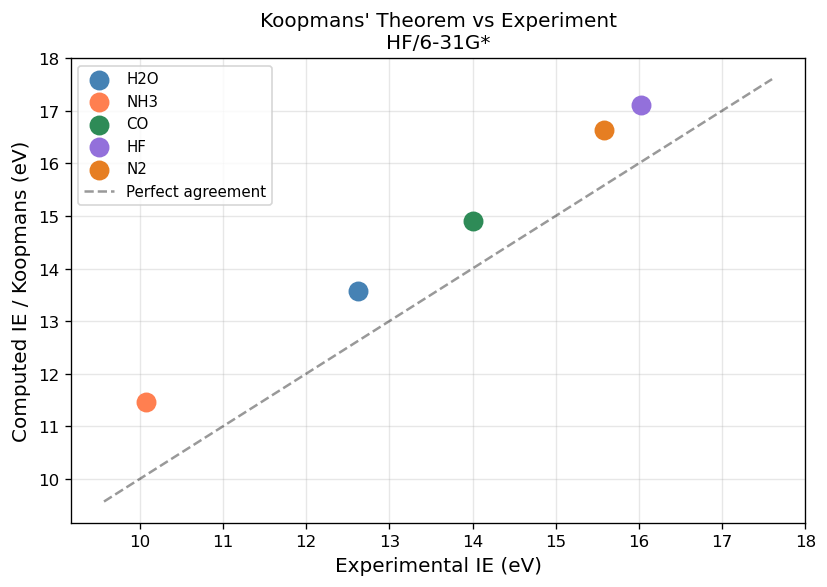

CPU times: user 1.9 s, sys: 27.8 ms, total: 1.92 s
Wall time: 777 ms


In [16]:
%%time
# ------------------------------------------------------------------
# Koopmans' Theorem: IE ≈ -ε_HOMO
# ------------------------------------------------------------------
# Compare predicted ionization energies (-HOMO energy) with experiment

molecules_IE = {
    'H2O':  ('O 0 0 0; H 0 0.757 -0.469; H 0 -0.757 -0.469', 12.62),
    'NH3':  ('N 0 0 0.116; H 0 0.939 -0.269; H 0.814 -0.469 -0.269; H -0.814 -0.469 -0.269', 10.07),
    'CO':   ('C 0 0 0; O 0 0 1.128', 14.01),
    'HF':   ('H 0 0 0; F 0 0 0.917', 16.03),
    'N2':   ('N 0 0 0; N 0 0 1.098', 15.58),
}

koopman_results = []
for name, (atom_str, exp_ie) in molecules_IE.items():
    mol = gto.Mole()
    mol.atom = atom_str
    mol.basis = '6-31g*'
    mol.verbose = 0
    mol.build()
    
    mf = scf.RHF(mol)
    mf.verbose = 0
    mf.kernel()
    
    mo_e = mf.mo_energy
    mo_occ = mf.mo_occ
    homo_idx = np.where(mo_occ > 0)[0][-1]
    comp_ie = -mo_e[homo_idx] * 27.2114
    
    koopman_results.append({
        'Molecule': name,
        'Computed IE (eV)': round(comp_ie, 2),
        'Experimental IE (eV)': exp_ie,
        'Error (eV)': round(comp_ie - exp_ie, 2),
    })

df_k = pd.DataFrame(koopman_results)
print("Koopmans' Theorem: HF/6-31G* Ionization Energies")
print(df_k.to_string(index=False))

mae = np.mean(np.abs(df_k['Error (eV)']))
print(f"\nMean Absolute Error: {mae:.2f} eV")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
x = np.array(df_k['Experimental IE (eV)'])
y = np.array(df_k['Computed IE (eV)'])
names = list(df_k['Molecule'])

colors_mol = ['steelblue', 'coral', 'seagreen', 'mediumpurple', '#E67E22']
for xi, yi, name, col in zip(x, y, names, colors_mol):
    ax.scatter(xi, yi, color=col, s=120, zorder=5, label=name)

# y=x line (perfect agreement)
lim_min = min(min(x), min(y)) - 0.5
lim_max = max(max(x), max(y)) + 0.5
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.4, label='Perfect agreement')

ax.set_xlabel('Experimental IE (eV)', fontsize=12)
ax.set_ylabel('Computed IE / Koopmans (eV)', fontsize=12)
ax.set_title("Koopmans' Theorem vs Experiment\nHF/6-31G*", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🔬 Research Connection

Hartree-Fock theory, despite its limitations, remains fundamental:

- **Starting point for coupled cluster**: CCSD(T), the "gold standard" of quantum chemistry,
  builds on HF via perturbation theory and cluster operators

  **Also a good initialization point to explore the complete active space (CAS) calculations,
  like number of orbitals, electrons required for CAS treatment.**
  
- **HF in DFT**: The Kohn-Sham equations have the same structure as HF, but replace
  the exact exchange with an approximate exchange-correlation functional.
- **Orbital analysis**: HF molecular orbitals (sigma, pi, lone pairs) provide chemical
  intuition used daily in organic and organometallic chemistry.
- **Limitations drive innovation**: The failures of HF (correlation energy, dispersion,
  open-shell systems) motivated the entire field of post-HF and DFT methods.

**Read more:** Roothaan, C.C.J. (1951). *Rev. Mod. Phys.* **23**, 69, https://doi.org/10.1103/RevModPhys.23.69 — derived
the matrix HF equations (Roothaan equations) that all modern QC codes implement.

## 📋 Summary

| Concept | Key Result |
|---------|----------|
| Slater determinant | Antisymmetric wavefunction for N fermions; incorporates Pauli principle |
| Fock operator | $\hat{F} = \hat{h} + \hat{J} - \hat{K}$; mean-field treatment of e-e repulsion |
| SCF procedure | Iterative diagonalization until density matrix converges |
| Koopmans' theorem | $\text{IE} \approx -\epsilon_{HOMO}$; error ~0.5-1.5 eV for typical molecules |
| HF correlation energy | $E_{corr} = E_{exact} - E_{HF} \approx$ -0.5 to -1.5 eV/electron pair |
| H₂ dissociation | RHF fails; needs multi-reference methods or UHF |

**Post-HF hierarchy** (increasing accuracy, increasing cost):
HF → MP2 → CCSD → CCSD(T) → FCI

**DFT alternative** (similar cost to HF, better accuracy):
DFT captures ~80-90% of correlation energy implicitly through $E_{xc}$

## 📝 Exercises

1. **Basis set effect on Koopmans'**: Redo the Koopmans' theorem calculation using
   `def2-TZVP` instead of `6-31G*`. Does a larger basis set improve agreement with
   experiment? Why or why not?

2. **SCF starting point**: Try using `mf.init_guess = 'atom'` vs `mf.init_guess = 'huckel'`
   for the water SCF calculation. Does the starting guess affect the converged energy?
   Does it affect the number of iterations?

3. **Open-shell HF**: CO has a singlet ground state. Run UHF (unrestricted HF) on 
   the triplet state of CO using `mol.spin = 2` and `scf.UHF(mol)`.
   What is the energy difference between singlet and triplet?

4. **HOMO-LUMO gap trends**: Compute HF/6-31G* HOMO-LUMO gaps for 
   ethylene (C₂H₄), butadiene (C₄H₆), hexatriene (C₆H₈), and benzene (C₆H₆).
   Plot gap vs number of double bonds. What trend do you observe?

5. **Correlation energy estimate**: Compute RHF and MP2 energies for H₂O with cc-pVTZ.
   What fraction of the correlation energy does MP2 recover (compared to ~-0.37 Ha
   for the experimental correlation energy of water)?

In [9]:
# ------------------------------------------------------------------
# Koopmans' Theorem with def2-TZVP
# ------------------------------------------------------------------

molecules_IE = {
    'H2O':  ('O 0 0 0; H 0 0.757 -0.469; H 0 -0.757 -0.469', 12.62),
    'NH3':  ('N 0 0 0.116; H 0 0.939 -0.269; H 0.814 -0.469 -0.269; H -0.814 -0.469 -0.269', 10.07),
    'CO':   ('C 0 0 0; O 0 0 1.128', 14.01),
    'HF':   ('H 0 0 0; F 0 0 0.917', 16.03),
    'N2':   ('N 0 0 0; N 0 0 1.098', 15.58),
}

koopman_results = []

for name, (atom_str, exp_ie) in molecules_IE.items():

    mol = gto.Mole()
    mol.atom = atom_str

    # Larger modern basis set
    mol.basis = 'def2-TZVP'

    mol.verbose = 0
    mol.build()

    mf = scf.RHF(mol)
    mf.verbose = 0
    mf.kernel()

    mo_e = mf.mo_energy
    mo_occ = mf.mo_occ

    homo_idx = np.where(mo_occ > 0)[0][-1]

    comp_ie = -mo_e[homo_idx] * 27.2114

    koopman_results.append({
        'Molecule': name,
        'Computed IE (eV)': round(comp_ie, 2),
        'Experimental IE (eV)': exp_ie,
        'Error (eV)': round(comp_ie - exp_ie, 2),
    })

df_k = pd.DataFrame(koopman_results)

print("Koopmans' Theorem: HF/def2-TZVP Ionization Energies")
print(df_k.to_string(index=False))

mae = np.mean(np.abs(df_k['Error (eV)']))
print(f"\nMean Absolute Error: {mae:.2f} eV")

Koopmans' Theorem: HF/def2-TZVP Ionization Energies
Molecule  Computed IE (eV)  Experimental IE (eV)  Error (eV)
     H2O             13.90                 12.62        1.28
     NH3             11.66                 10.07        1.59
      CO             15.09                 14.01        1.08
      HF             17.62                 16.03        1.59
      N2             16.70                 15.58        1.12

Mean Absolute Error: 1.33 eV


Using the larger def2-TZVP basis set slightly improved some of the Koopmans’ theorem ionization energies because the orbitals and electron density are described more accurately with a more flexible basis. However, the overall agreement with experiment did not improve dramatically. This is because the dominant source of error is not the basis set itself, but the Hartree–Fock and Koopmans approximations. Koopmans’ theorem assumes frozen orbitals during ionization and neglects electron correlation, so even with a larger basis set the calculated ionization energies remain systematically imperfect. Therefore, increasing the basis set reduces basis set incompleteness error, but it cannot fully correct the underlying physical approximations of HF theory.


A better way to improve the approximation would be to use a more advanced electronic structure method that includes electron correlation and orbital relaxation effects, rather than only increasing the basis set size. For example, methods such as MP2, coupled cluster (CCSD(T)), or density functional theory (DFT) can provide more accurate ionization energies because they go beyond the mean-field Hartree–Fock approximation. Another major improvement would be to compute the ionization energy directly using a ΔSCF approach:

IE = E(N-1) - E(N)

where separate calculations are performed for the neutral molecule and the ionized molecule. This allows the orbitals to relax after electron removal and usually gives much better agreement with experiment than Koopmans’ theorem alone.

In [11]:
# ------------------------------------------------------------------
# SCF Initial Guess Comparison
# ------------------------------------------------------------------

from pyscf import gto, scf

def run_scf(init_guess_method):

    energies = []

    def callback(envs):
        energies.append(envs['e_tot'])

    mol = gto.Mole()
    mol.atom = 'O 0 0 0; H 0 0.757 -0.469; H 0 -0.757 -0.469'
    mol.basis = '6-31g*'
    mol.verbose = 0
    mol.build()

    mf = scf.RHF(mol)

    # Set initial guess
    mf.init_guess = init_guess_method

    mf.verbose = 0
    mf.callback = callback

    final_energy = mf.kernel()

    return final_energy, len(energies), energies


# Run with atomic guess
e_atom, n_atom, energies_atom = run_scf('atom')

# Run with Huckel guess
e_huckel, n_huckel, energies_huckel = run_scf('huckel')

print("SCF Initial Guess Comparison")
print("-" * 40)

print(f"Atomic guess:")
print(f"  Final Energy: {e_atom:.10f} Ha")
print(f"  Iterations:   {n_atom}")

print()

print(f"Huckel guess:")
print(f"  Final Energy: {e_huckel:.10f} Ha")
print(f"  Iterations:   {n_huckel}")

SCF Initial Guess Comparison
----------------------------------------
Atomic guess:
  Final Energy: -75.9992646967 Ha
  Iterations:   8

Huckel guess:
  Final Energy: -75.9992646967 Ha
  Iterations:   8


Changing the SCF initial guess from atom to huckel did not affect the final converged energy for water. Both calculations converged to the same Hartree–Fock energy, -75.9992646967 Ha. This makes sense because water is a simple closed-shell molecule, so both starting guesses lead to the same stable self-consistent solution.

In this calculation, the starting guess also did not affect the number of SCF iterations. Both the atom guess and the huckel guess converged in 8 iterations. In principle, the initial guess can affect the number of iterations because a better guess may start closer to the final electron density. However, for this water calculation, both guesses were good enough that PySCF reached convergence in the same number of steps.

Therefore, for this system, the SCF starting guess affected neither the converged energy nor the number of iterations. For more difficult systems, such as transition-metal complexes, radicals, stretched bonds, or systems with near-degenerate orbitals, the starting guess can matter much more and may affect convergence speed or even which SCF solution is obtained.

In [12]:
# ------------------------------------------------------------------
# Open-shell HF: Singlet CO vs Triplet CO
# ------------------------------------------------------------------
# Goal:
# CO has a singlet ground state.
# Here we compare the normal singlet RHF energy with a triplet UHF energy.
#
# In PySCF:
# mol.spin = N_alpha - N_beta = 2S
#
# Singlet: S = 0, so mol.spin = 0
# Triplet: S = 1, so mol.spin = 2

from pyscf import gto, scf
import numpy as np
import pandas as pd

hartree_to_ev = 27.2114
hartree_to_kcal = 627.509

co_geom = 'C 0 0 0; O 0 0 1.128'
basis = '6-31g*'


# ------------------------------------------------------------------
# Singlet CO: RHF calculation
# ------------------------------------------------------------------

mol_singlet = gto.Mole()
mol_singlet.atom = co_geom
mol_singlet.basis = basis
mol_singlet.charge = 0
mol_singlet.spin = 0       # singlet: N_alpha - N_beta = 0
mol_singlet.verbose = 0
mol_singlet.build()

mf_singlet = scf.RHF(mol_singlet)
mf_singlet.verbose = 0
e_singlet = mf_singlet.kernel()


# ------------------------------------------------------------------
# Triplet CO: UHF calculation
# ------------------------------------------------------------------

mol_triplet = gto.Mole()
mol_triplet.atom = co_geom
mol_triplet.basis = basis
mol_triplet.charge = 0
mol_triplet.spin = 2       # triplet: S = 1, so 2S = 2
mol_triplet.verbose = 0
mol_triplet.build()

mf_triplet = scf.UHF(mol_triplet)
mf_triplet.verbose = 0
e_triplet = mf_triplet.kernel()

# <S^2> diagnostic for UHF spin contamination
s2, multiplicity = mf_triplet.spin_square()


# ------------------------------------------------------------------
# Energy difference
# ------------------------------------------------------------------

delta_E_ha = e_triplet - e_singlet
delta_E_ev = delta_E_ha * hartree_to_ev
delta_E_kcal = delta_E_ha * hartree_to_kcal

results = pd.DataFrame([
    {
        "State": "Singlet CO",
        "Method": "RHF",
        "mol.spin": 0,
        "Energy (Ha)": e_singlet,
    },
    {
        "State": "Triplet CO",
        "Method": "UHF",
        "mol.spin": 2,
        "Energy (Ha)": e_triplet,
    },
])

print("Singlet vs Triplet CO")
print(results.to_string(index=False))

print("\nEnergy difference:")
print(f"ΔE = E_triplet - E_singlet")
print(f"ΔE = {delta_E_ha:.8f} Ha")
print(f"ΔE = {delta_E_ev:.3f} eV")
print(f"ΔE = {delta_E_kcal:.2f} kcal/mol")

print("\nUHF spin diagnostic for triplet:")
print(f"<S^2> = {s2:.4f}")
print(f"Spin multiplicity = {multiplicity:.4f}")

print("\nInterpretation:")
if delta_E_ha > 0:
    print("The triplet state is higher in energy than the singlet state.")
    print("This agrees with the fact that CO has a singlet ground state.")
else:
    print("The triplet state is lower in energy, which would be unexpected for CO at this level.")

Singlet vs Triplet CO
     State Method  mol.spin  Energy (Ha)
Singlet CO    RHF         0  -112.736788
Triplet CO    UHF         2  -112.538472

Energy difference:
ΔE = E_triplet - E_singlet
ΔE = 0.19831600 Ha
ΔE = 5.396 eV
ΔE = 124.45 kcal/mol

UHF spin diagnostic for triplet:
<S^2> = 2.0916
Spin multiplicity = 3.0604

Interpretation:
The triplet state is higher in energy than the singlet state.
This agrees with the fact that CO has a singlet ground state.


### Singlet–Triplet Energy Difference for CO

The calculated singlet RHF energy of CO was:

$$
E_{\text{singlet}} = -112.736788 \ \text{Ha}
$$

The calculated triplet UHF energy of CO was:

$$
E_{\text{triplet}} = -112.538472 \ \text{Ha}
$$

The singlet–triplet energy difference is:

$$
\Delta E = E_{\text{triplet}} - E_{\text{singlet}}
$$

$$
\Delta E = (-112.538472) - (-112.736788)
$$

$$
\Delta E = 0.198316 \ \text{Ha}
$$

Converting to more useful units:

$$
\Delta E = 0.198316 \times 27.2114 = 5.396 \ \text{eV}
$$

$$
\Delta E = 0.198316 \times 627.509 = 124.45 \ \text{kcal/mol}
$$

Therefore, the triplet state is higher in energy than the singlet state by:

$$
\boxed{\Delta E = 0.198316 \ \text{Ha} = 5.396 \ \text{eV} = 124.45 \ \text{kcal/mol}}
$$

This means that the singlet state is more stable than the triplet state at the HF/6-31G* level. This agrees with the fact that CO has a singlet ground state.

The UHF triplet calculation also gave:

$$
\langle S^2 \rangle = 2.0916
$$

For an ideal triplet state:

$$
S = 1
$$

$$
S(S+1) = 1(1+1) = 2
$$

So the calculated value of $\langle S^2 \rangle = 2.0916$ is close to the ideal triplet value of 2. The small difference indicates mild spin contamination. Spin contamination means that the UHF wavefunction is not a perfectly pure triplet spin state, because the alpha and beta orbitals are allowed to have different spatial shapes.



Besides RHF and UHF, we could also use ROHF, MP2,  or multireference methods.

RHF is best for closed-shell singlet systems where all electrons are paired. 
UHF is useful for open-shell systems such as radicals and triplets, but it can suffer from spin contamination. 
ROHF, or restricted open-shell Hartree–Fock, is another option for open-shell systems. It keeps a more spin-pure wavefunction than UHF, so it can be better when we care about the correct spin state.


I used an LLM for formatting


HF/6-31G* HOMO-LUMO gaps
  Molecule Formula  Double bonds  E_HF (Ha)  HOMO (eV)  LUMO (eV)  Gap (eV)  N_basis
  Ethylene    C2H4             1   -78.0303   -10.0426     4.8548   14.8975       36
 Butadiene    C4H6             2  -154.5246    -5.9318     2.3353    8.2671       68
Hexatriene    C6H8             3  -231.0537    -5.2423     2.4510    7.6933      100
   Benzene    C6H6             3  -230.7016    -8.9500     3.9944   12.9444       96


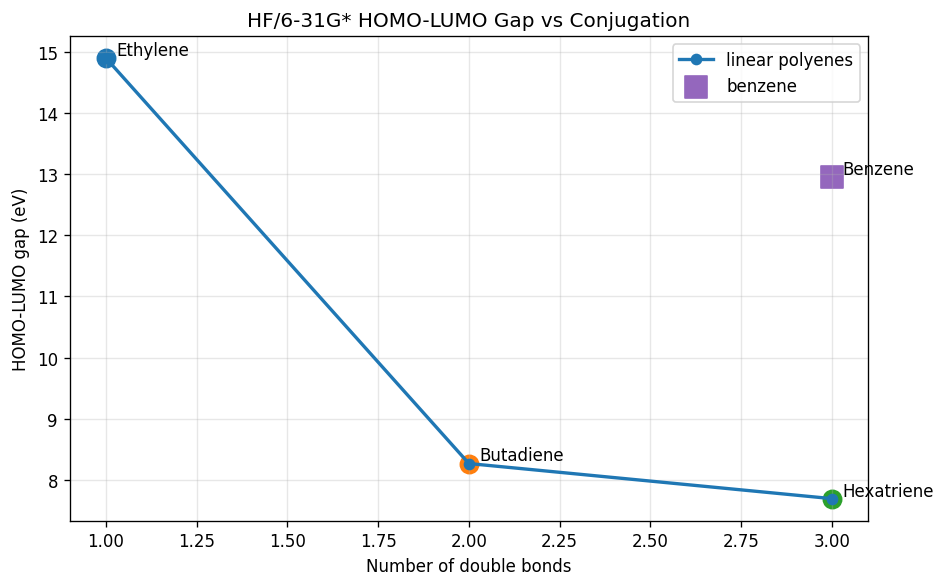

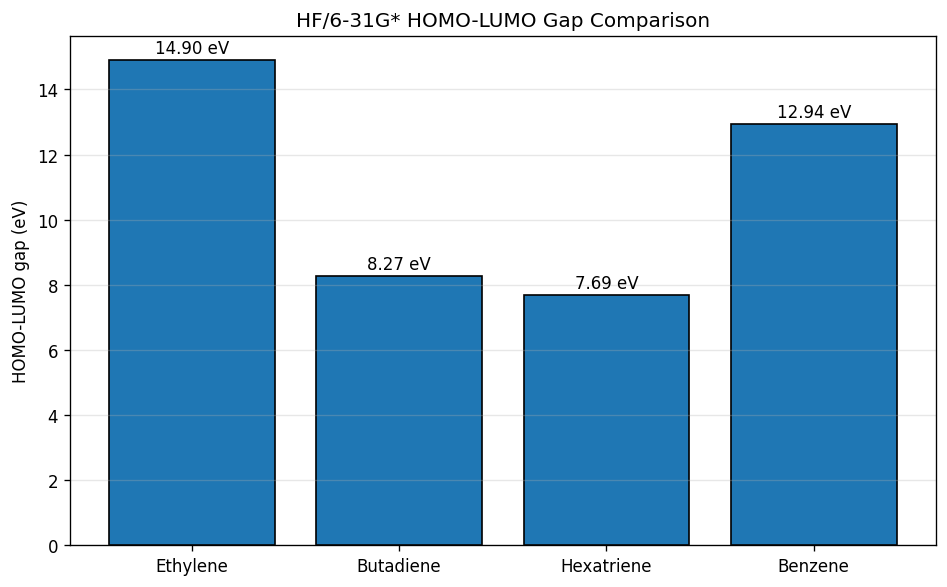


Interpretation:
As the linear conjugated chain gets longer, the HOMO-LUMO gap decreases.
Ethylene has one double bond, butadiene has two, and hexatriene has three.
More conjugation spreads the pi electrons over a larger system.
This makes the pi molecular orbital energy levels closer together.
Therefore, the HOMO-LUMO gap becomes smaller.
Benzene also has three formal double bonds, but it is cyclic and aromatic,
so it should not be treated as just another linear polyene point.


In [14]:
# ------------------------------------------------------------------
# HOMO-LUMO gap trends in conjugated molecules
# ------------------------------------------------------------------
# Goal:
# Compute HF/6-31G* HOMO-LUMO gaps for:
#   ethylene, butadiene, hexatriene, benzene
#
# Then plot HOMO-LUMO gap vs number of double bonds.
#
# HOMO = Highest Occupied Molecular Orbital
# LUMO = Lowest Unoccupied Molecular Orbital
# Gap = E_LUMO - E_HOMO
#
# A smaller HOMO-LUMO gap usually means electrons are easier to excite.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyscf import gto, scf

# Conversion factor
hartree_to_ev = 27.2114

# ------------------------------------------------------------------
# Approximate geometries in Angstrom
# ------------------------------------------------------------------
# These geometries are reasonable for a trend exercise.
# They are not optimized geometries.
#
# The linear polyenes are placed mostly along the x-axis.
# Benzene is placed as a regular hexagon in the xy-plane.

molecules = {
    "Ethylene": {
        "formula": "C2H4",
        "double_bonds": 1,
        "atom": """
        C   -0.6700   0.0000   0.0000
        C    0.6700   0.0000   0.0000
        H   -1.2300   0.9300   0.0000
        H   -1.2300  -0.9300   0.0000
        H    1.2300   0.9300   0.0000
        H    1.2300  -0.9300   0.0000
        """
    },

    "Butadiene": {
        "formula": "C4H6",
        "double_bonds": 2,
        "atom": """
        C   -2.0100   0.0000   0.0000
        C   -0.6700   0.0000   0.0000
        C    0.7900   0.0000   0.0000
        C    2.1300   0.0000   0.0000
        H   -2.5700   0.9300   0.0000
        H   -2.5700  -0.9300   0.0000
        H   -0.1100   0.9300   0.0000
        H    0.2300  -0.9300   0.0000
        H    2.6900   0.9300   0.0000
        H    2.6900  -0.9300   0.0000
        """
    },

    "Hexatriene": {
        "formula": "C6H8",
        "double_bonds": 3,
        "atom": """
        C   -3.3500   0.0000   0.0000
        C   -2.0100   0.0000   0.0000
        C   -0.5500   0.0000   0.0000
        C    0.7900   0.0000   0.0000
        C    2.2500   0.0000   0.0000
        C    3.5900   0.0000   0.0000
        H   -3.9100   0.9300   0.0000
        H   -3.9100  -0.9300   0.0000
        H   -1.4500   0.9300   0.0000
        H   -1.1100  -0.9300   0.0000
        H    0.2300   0.9300   0.0000
        H    1.3500  -0.9300   0.0000
        H    4.1500   0.9300   0.0000
        H    4.1500  -0.9300   0.0000
        """
    },

    "Benzene": {
        "formula": "C6H6",
        "double_bonds": 3,
        "atom": """
        C    1.3970   0.0000   0.0000
        C    0.6985   1.2098   0.0000
        C   -0.6985   1.2098   0.0000
        C   -1.3970   0.0000   0.0000
        C   -0.6985  -1.2098   0.0000
        C    0.6985  -1.2098   0.0000
        H    2.4790   0.0000   0.0000
        H    1.2395   2.1469   0.0000
        H   -1.2395   2.1469   0.0000
        H   -2.4790   0.0000   0.0000
        H   -1.2395  -2.1469   0.0000
        H    1.2395  -2.1469   0.0000
        """
    }
}

# ------------------------------------------------------------------
# Run HF/6-31G* calculations
# ------------------------------------------------------------------

results = []

for name, info in molecules.items():

    mol = gto.Mole()
    mol.atom = info["atom"]
    mol.basis = "6-31g*"
    mol.charge = 0
    mol.spin = 0
    mol.unit = "Angstrom"
    mol.verbose = 0
    mol.build()

    # RHF = restricted Hartree-Fock.
    # This is okay here because these are closed-shell neutral molecules.
    mf = scf.RHF(mol)
    mf.verbose = 0
    energy = mf.kernel()

    # Molecular orbital energies and occupations
    mo_e = mf.mo_energy
    mo_occ = mf.mo_occ

    # Find HOMO and LUMO indices
    homo_idx = np.where(mo_occ > 0)[0][-1]
    lumo_idx = homo_idx + 1

    # Convert orbital energies from Hartree to eV
    homo_ev = mo_e[homo_idx] * hartree_to_ev
    lumo_ev = mo_e[lumo_idx] * hartree_to_ev

    # HOMO-LUMO gap
    gap_ev = lumo_ev - homo_ev

    results.append({
        "Molecule": name,
        "Formula": info["formula"],
        "Double bonds": info["double_bonds"],
        "E_HF (Ha)": energy,
        "HOMO (eV)": homo_ev,
        "LUMO (eV)": lumo_ev,
        "Gap (eV)": gap_ev,
        "N_basis": mol.nao_nr()
    })

# ------------------------------------------------------------------
# Make table
# ------------------------------------------------------------------

df_gap = pd.DataFrame(results)

print("HF/6-31G* HOMO-LUMO gaps")
print(df_gap.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ------------------------------------------------------------------
# Plot: gap vs number of double bonds
# ------------------------------------------------------------------

plt.figure(figsize=(8, 5))

# Plot and label every molecule
for _, row in df_gap.iterrows():
    plt.scatter(row["Double bonds"], row["Gap (eV)"], s=120)

    plt.text(
        row["Double bonds"] + 0.03,
        row["Gap (eV)"] + 0.05,
        row["Molecule"],
        fontsize=10
    )

# Connect only the linear polyene series:
# ethylene -> butadiene -> hexatriene
linear_polyenes = df_gap[df_gap["Molecule"].isin(["Ethylene", "Butadiene", "Hexatriene"])]
linear_polyenes = linear_polyenes.sort_values("Double bonds")

plt.plot(
    linear_polyenes["Double bonds"],
    linear_polyenes["Gap (eV)"],
    "o-",
    linewidth=2,
    label="linear polyenes"
)

# Mark benzene separately because it is cyclic/aromatic, not a linear triene.
benzene = df_gap[df_gap["Molecule"] == "Benzene"]

plt.scatter(
    benzene["Double bonds"],
    benzene["Gap (eV)"],
    s=160,
    marker="s",
    label="benzene"
)

plt.xlabel("Number of double bonds")
plt.ylabel("HOMO-LUMO gap (eV)")
plt.title("HF/6-31G* HOMO-LUMO Gap vs Conjugation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Optional second plot: bar chart
# ------------------------------------------------------------------

plt.figure(figsize=(8, 5))

bars = plt.bar(
    df_gap["Molecule"],
    df_gap["Gap (eV)"],
    edgecolor="black"
)

plt.ylabel("HOMO-LUMO gap (eV)")
plt.title("HF/6-31G* HOMO-LUMO Gap Comparison")
plt.grid(axis="y", alpha=0.3)

for bar, gap in zip(bars, df_gap["Gap (eV)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{gap:.2f} eV",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Print interpretation
# ------------------------------------------------------------------

print("\nInterpretation:")
print("As the linear conjugated chain gets longer, the HOMO-LUMO gap decreases.")
print("Ethylene has one double bond, butadiene has two, and hexatriene has three.")
print("More conjugation spreads the pi electrons over a larger system.")
print("This makes the pi molecular orbital energy levels closer together.")
print("Therefore, the HOMO-LUMO gap becomes smaller.")
print("Benzene also has three formal double bonds, but it is cyclic and aromatic,")
print("so it should not be treated as just another linear polyene point.")

In [15]:
# ------------------------------------------------------------------
# Correlation energy estimate for H2O
# RHF vs MP2 with cc-pVTZ
# ------------------------------------------------------------------
# Goal:
# Compute:
#   1. RHF energy
#   2. MP2 total energy
#   3. MP2 correlation energy
#   4. Fraction of experimental correlation energy recovered
#
# Correlation energy:
#   E_corr = E_exact - E_HF
#
# MP2 estimates this as:
#   E_corr_MP2 = E_MP2 - E_HF
#
# Given approximate experimental correlation energy for water:
#   E_corr_exp ≈ -0.37 Ha

from pyscf import gto, scf, mp
import pandas as pd

# Conversion factors
hartree_to_ev = 27.2114
hartree_to_kcal = 627.509

# Approximate experimental correlation energy of water
e_corr_exp = -0.37  # Hartree

# Water geometry
water_geom = """
O  0.000000   0.000000   0.000000
H  0.000000   0.757000  -0.469000
H  0.000000  -0.757000  -0.469000
"""

# ------------------------------------------------------------------
# Build molecule
# ------------------------------------------------------------------

mol = gto.Mole()
mol.atom = water_geom
mol.basis = "cc-pVTZ"
mol.charge = 0
mol.spin = 0
mol.unit = "Angstrom"
mol.verbose = 0
mol.build()

# ------------------------------------------------------------------
# RHF calculation
# ------------------------------------------------------------------

mf = scf.RHF(mol)
mf.verbose = 0
e_rhf = mf.kernel()

# ------------------------------------------------------------------
# MP2 calculation
# ------------------------------------------------------------------

mpt = mp.MP2(mf)
mpt.verbose = 0

# emp2_corr is the MP2 correlation correction
# t2 amplitudes are returned as the second output, but we do not need them here.
emp2_corr, t2 = mpt.kernel()

# MP2 total energy
e_mp2_total = e_rhf + emp2_corr

# Fraction of experimental correlation energy recovered
fraction_recovered = emp2_corr / e_corr_exp
percent_recovered = 100 * fraction_recovered

# ------------------------------------------------------------------
# Print results
# ------------------------------------------------------------------

results = pd.DataFrame([
    {
        "Quantity": "RHF energy",
        "Value (Ha)": e_rhf,
        "Value (eV)": e_rhf * hartree_to_ev,
        "Value (kcal/mol)": e_rhf * hartree_to_kcal,
    },
    {
        "Quantity": "MP2 total energy",
        "Value (Ha)": e_mp2_total,
        "Value (eV)": e_mp2_total * hartree_to_ev,
        "Value (kcal/mol)": e_mp2_total * hartree_to_kcal,
    },
    {
        "Quantity": "MP2 correlation energy",
        "Value (Ha)": emp2_corr,
        "Value (eV)": emp2_corr * hartree_to_ev,
        "Value (kcal/mol)": emp2_corr * hartree_to_kcal,
    },
    {
        "Quantity": "Approx. experimental correlation energy",
        "Value (Ha)": e_corr_exp,
        "Value (eV)": e_corr_exp * hartree_to_ev,
        "Value (kcal/mol)": e_corr_exp * hartree_to_kcal,
    },
])

print("H2O correlation energy estimate: RHF vs MP2 / cc-pVTZ")
print(results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\nFraction recovered:")
print(f"Fraction = E_corr_MP2 / E_corr_exp")
print(f"Fraction = ({emp2_corr:.6f} Ha) / ({e_corr_exp:.6f} Ha)")
print(f"Fraction = {fraction_recovered:.4f}")
print(f"Percent recovered = {percent_recovered:.2f}%")

H2O correlation energy estimate: RHF vs MP2 / cc-pVTZ
                               Quantity  Value (Ha)   Value (eV)  Value (kcal/mol)
                             RHF energy  -76.049787 -2069.421180     -47721.925929
                       MP2 total energy  -76.320068 -2076.775889     -47891.529330
                 MP2 correlation energy   -0.270280    -7.354709       -169.603400
Approx. experimental correlation energy   -0.370000   -10.068218       -232.178330

Fraction recovered:
Fraction = E_corr_MP2 / E_corr_exp
Fraction = (-0.270280 Ha) / (-0.370000 Ha)
Fraction = 0.7305
Percent recovered = 73.05%


The RHF calculation gives the mean-field reference energy for water, while the MP2 calculation adds a second-order perturbative correction for electron correlation. The MP2 correlation energy is the difference E_MP2 - E_RHF. Comparing this value to the approximate experimental correlation energy of water, about -0.37 Ha, gives the fraction of correlation energy recovered by MP2. MP2 should recover a large fraction of the correlation energy, but not all of it, because MP2 only includes correlation through second-order perturbation theory. It improves substantially over RHF, but it is still an approximate single-reference method and does not include all higher-order correlation effects.

---

# 03 — DFT Fundamentals: From Hohenberg-Kohn to Modern Functionals

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/03_dft_fundamentals.ipynb)

## 🎯 Learning Objectives

- The two Hohenberg-Kohn theorems
- The Kohn-Sham DFT formalism and its connection to HF
- Exchange-correlation (XC) functionals on Jacob's Ladder
- LDA, GGA, meta-GGA, hybrid, and double-hybrid functionals
- Dispersion corrections (DFT-D3, D4)
- How to choose an appropriate functional for a given chemical problem

## Theory: From Density to Energy

### 3.1 Hohenberg-Kohn Theorems (1964)

DFT is built on two exact theorems by Hohenberg and Kohn:

**Theorem 1 (Existence):** The external potential $v_{ext}(\mathbf{r})$ — and hence the
total energy — is a unique functional of the ground-state electron density $n_0(\mathbf{r})$:

$$E = E[n_0]$$

**Theorem 2 (Variational principle):** The universal functional $F[n]$ delivers
the ground-state energy if and only if the true ground-state density is used:

$$E[n] \geq E_0 \quad \text{for all } n \neq n_0$$

These theorems establish that $n(\mathbf{r})$ — a function of only 3 spatial variables
— contains all information needed to determine the ground-state energy.

### 3.2 Kohn-Sham DFT (1965)

The practical implementation by Kohn and Sham introduces a fictitious non-interacting
reference system with the **same density** as the real interacting system.

The Kohn-Sham equations are:

$$\left[-\frac{1}{2}\nabla^2 + v_{eff}(\mathbf{r})\right]\phi_i(\mathbf{r}) = \epsilon_i \phi_i(\mathbf{r})$$

where the effective potential is:

$$v_{eff}(\mathbf{r}) = v_{ext}(\mathbf{r}) + \underbrace{\int \frac{n(\mathbf{r}')}{|\mathbf{r}-\mathbf{r}'|} d\mathbf{r}'}_{v_{Hartree}} + \underbrace{v_{xc}[n](\mathbf{r})}_{exchange-correlation}$$

The total DFT energy is:

$$E_{KS}[n] = T_s[n] + E_{ne}[n] + J[n] + E_{xc}[n]$$

where $T_s$ = kinetic energy of non-interacting electrons, $E_{ne}$ = nuclear-electron
attraction, $J$ = classical Coulomb (Hartree) energy, and $E_{xc}$ = exchange-correlation energy.

### 3.3 The Exchange-Correlation Functional

The exact $E_{xc}[n]$ is unknown. All DFT methods differ in how they approximate it.

$$E_{xc}[n] = E_x[n] + E_c[n]$$

**Exchange energy** $E_x$ accounts for the Fermi hole (Pauli antisymmetry),
**correlation energy** $E_c$ captures dynamic and static electron correlation.

### 3.4 Dispersion Interactions

Standard DFT functionals miss long-range London dispersion ($r^{-6}$ decay).
The DFT-D3 correction by Grimme adds:

$$E_{DFT-D3} = -\frac{1}{2}\sum_{i\neq j} s_6 \frac{C_6^{ij}}{r_{ij}^6} f_{damp}(r_{ij}) + s_8 \frac{C_8^{ij}}{r_{ij}^8} f_{damp}(r_{ij})$$

Use keywords in ORCA: `B3LYP-D3BJ/def2-SVP` or `PBE0-D3/def2-TZVP`

/tmp/ipykernel_4041972/2473571662.py:85: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


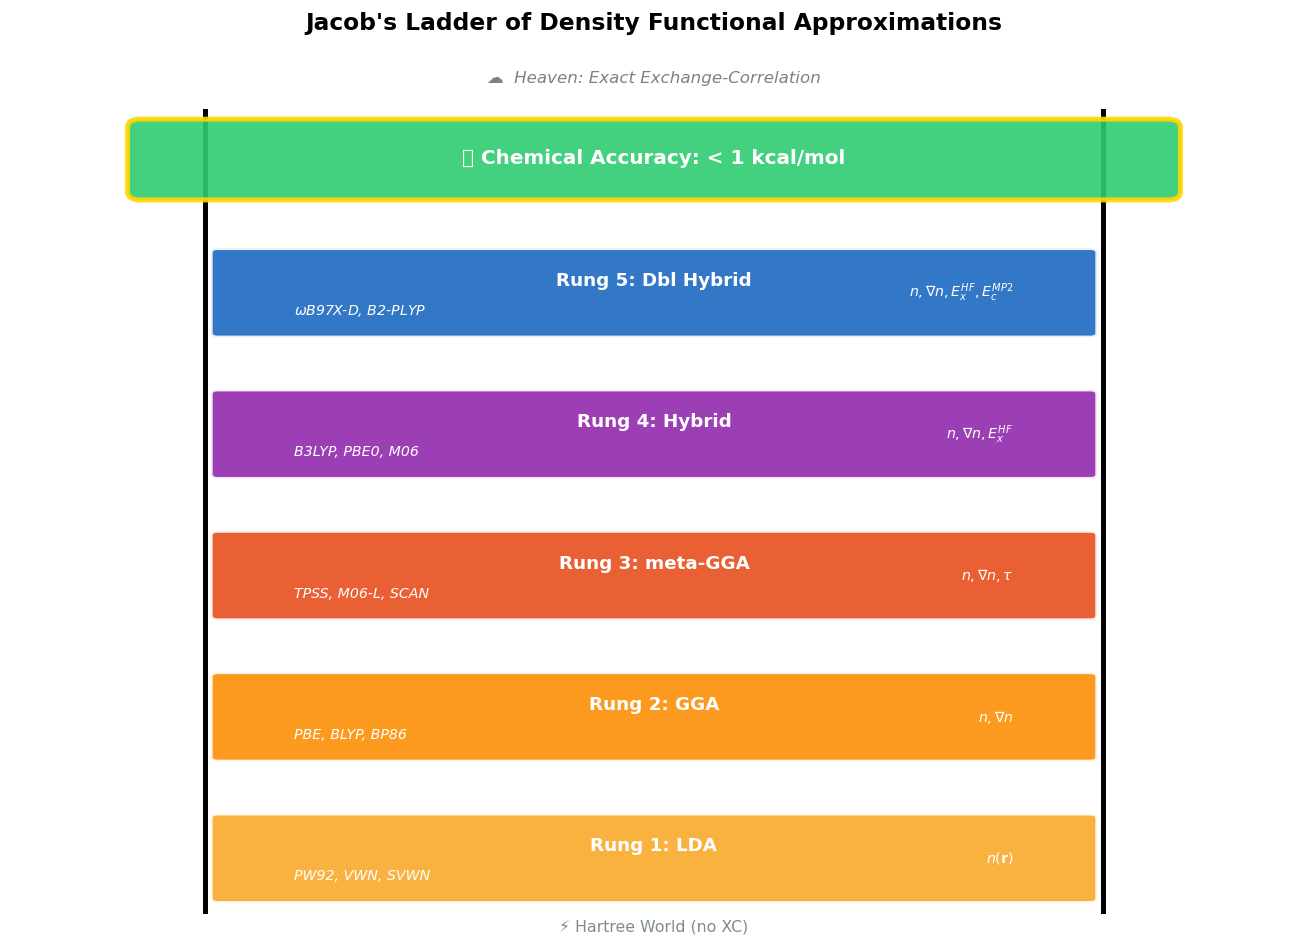

In [20]:
# =============================================================================
# Ch121a: Quantum Chemistry & DFT — Notebook 03: DFT Fundamentals
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from pyscf import gto, dft, scf

# ------------------------------------------------------------------
# Jacob's Ladder of DFT Approximations
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')

# Color gradient from bottom (warm) to top (cool)
rung_colors = ['#F9A825', '#FB8C00', '#E64A19', '#8E24AA', '#1565C0']
rung_data = [
    (1, 'Rung 1: LDA',      'Local Density\nApproximation',
     'PW92, VWN, SVWN',      r'$n(\mathbf{r})$'),
    (2, 'Rung 2: GGA',       'Generalized Gradient\nApproximation',
     'PBE, BLYP, BP86',       r'$n, \nabla n$'),
    (3, 'Rung 3: meta-GGA',  'Kinetic Energy Density',
     'TPSS, M06-L, SCAN',     r'$n, \nabla n, \tau$'),
    (4, 'Rung 4: Hybrid',    'Exact HF Exchange\n(partial)',
     'B3LYP, PBE0, M06',      r'$n, \nabla n, E_x^{HF}$'),
    (5, 'Rung 5: Dbl Hybrid','HF Exchange + MP2\nCorrelation',
     r'$\omega$B97X-D, B2-PLYP',r'$n, \nabla n, E_x^{HF}, E_c^{MP2}$'),
]

# Draw ladder poles
ax.plot([1.5, 1.5], [0.3, 10.2], 'k-', lw=3, zorder=1)
ax.plot([8.5, 8.5], [0.3, 10.2], 'k-', lw=3, zorder=1)

for (rung_num, title, subtitle, functionals, ingredients) in rung_data:
    y_center = rung_num * 1.75 - 0.8
    color = rung_colors[rung_num - 1]
    
    # Rung (horizontal bar)
    rung_patch = mpatches.FancyBboxPatch((1.6, y_center - 0.5), 6.8, 1.0,
                                          boxstyle="round,pad=0.05",
                                          facecolor=color, edgecolor='white',
                                          linewidth=2, alpha=0.88, zorder=2)
    ax.add_patch(rung_patch)
    
    # Title text
    ax.text(5.0, y_center + 0.15, title, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', zorder=3)
    
    # Functional examples (left)
    ax.text(2.2, y_center - 0.22, functionals, ha='left', va='center',
            fontsize=8.5, color='white', zorder=3, style='italic')
    
    # Ingredients (right)
    ax.text(7.8, y_center, ingredients, ha='right', va='center',
            fontsize=8.5, color='white', zorder=3)

# 'Chemical Accuracy' bar at top
ca_patch = mpatches.FancyBboxPatch((1.0, 9.2), 8.0, 0.8,
                                    boxstyle="round,pad=0.1",
                                    facecolor='#2ECC71', edgecolor='gold',
                                    linewidth=3, alpha=0.9, zorder=2)
ax.add_patch(ca_patch)
ax.text(5.0, 9.62, '🎯 Chemical Accuracy: < 1 kcal/mol',
        ha='center', va='center', fontsize=12, fontweight='bold',
        color='white', zorder=3)

# 'Heaven' / exact label
ax.text(5.0, 10.6, '☁  Heaven: Exact Exchange-Correlation',
        ha='center', va='center', fontsize=10, color='gray', style='italic')

# Ground label
ax.text(5.0, 0.1, '⚡ Hartree World (no XC)',
        ha='center', va='center', fontsize=9.5, color='#7F8C8D')

# Title
ax.set_title("Jacob's Ladder of Density Functional Approximations",
             fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

## I rendered the above but I like this below one more from 
**Best-Practice DFT Protocols for Basic Molecular Computational Chemistry**, Bursch et al. 
https://doi.org/10.1002/anie.202205735 Open access, **Very important work** 
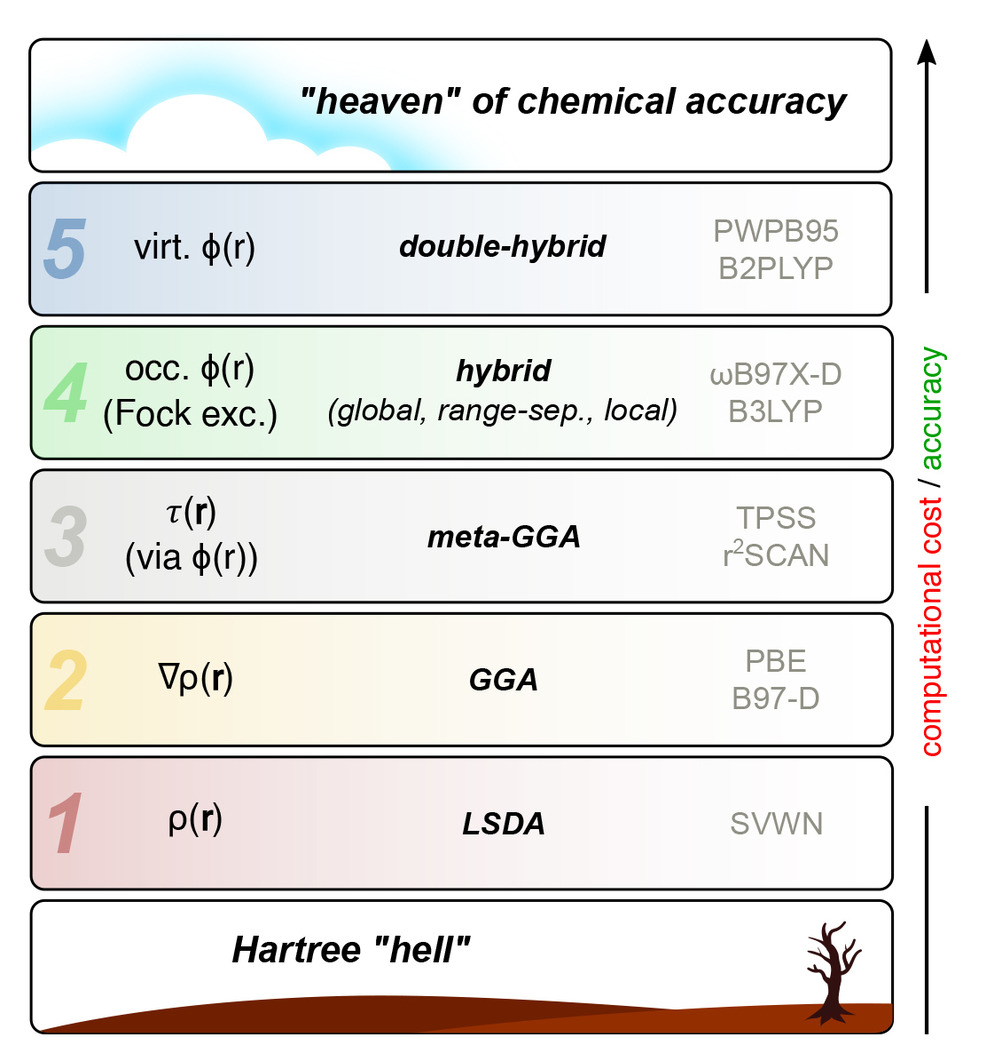

  SVWN     (LDA       ): E = -75.795146 Ha  μ = 2.024 D
  PBE      (GGA       ): E = -76.271966 Ha  μ = 1.935 D
  TPSS     (meta-GGA  ): E = -76.360001 Ha  μ = 1.936 D
  B3LYP    (Hybrid    ): E = -76.358122 Ha  μ = 1.981 D
  PBE0     (Hybrid    ): E = -76.276252 Ha  μ = 2.009 D


Functional Category  Energy (Ha)  Dipole (D)
      SVWN      LDA   -75.795146       2.024
       PBE      GGA   -76.271966       1.935
      TPSS meta-GGA   -76.360001       1.936
     B3LYP   Hybrid   -76.358122       1.981
      PBE0   Hybrid   -76.276252       2.009


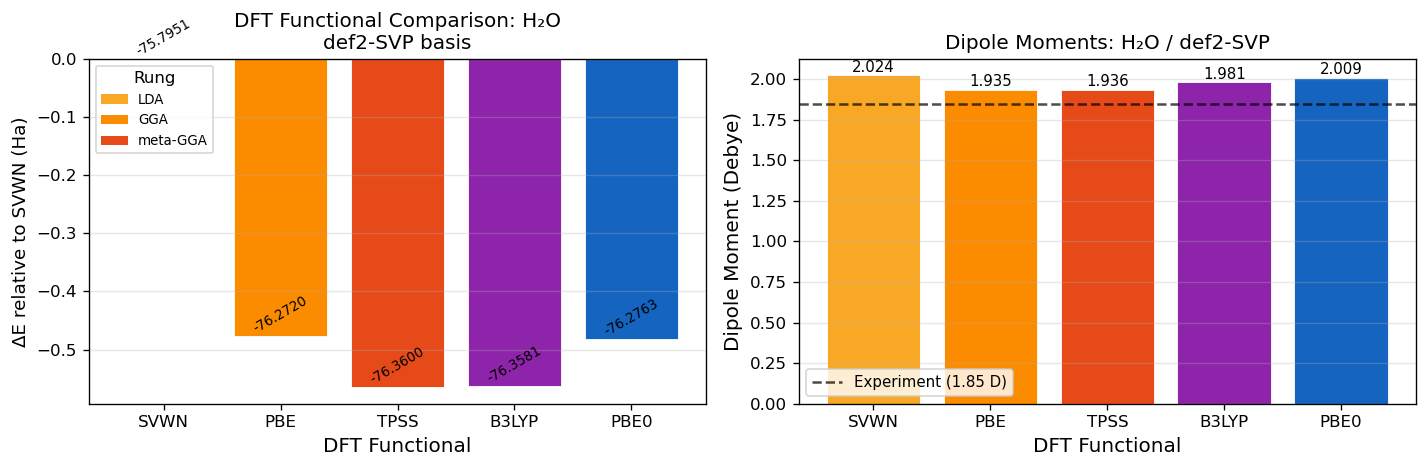

CPU times: user 32 s, sys: 55.8 ms, total: 32.1 s
Wall time: 8.72 s


In [21]:
%%time
# ------------------------------------------------------------------
# DFT Functional Comparison on H₂O / def2-SVP
# ------------------------------------------------------------------

mol = gto.Mole()
mol.atom = '''O  0.000000  0.000000  0.117176
H  0.000000  0.757001 -0.468704
H  0.000000 -0.757001 -0.468704'''
mol.basis = 'def2-SVP'
mol.verbose = 0
mol.build()

functionals = {
    'SVWN':  ('LDA',       '#F9A825'),
    'PBE':   ('GGA',       '#FB8C00'),
    'TPSS':  ('meta-GGA',  '#E64A19'),
    'B3LYP': ('Hybrid',    '#8E24AA'),
    'PBE0':  ('Hybrid',    '#1565C0'),
}

results = []
for func, (category, color) in functionals.items():
    mf = dft.RKS(mol)
    mf.xc = func
    mf.verbose = 0
    e = mf.kernel()
    dm = mf.make_rdm1()
    dip = mf.dip_moment(mol, dm, verbose=0)
    dip_mag = np.linalg.norm(dip)
    results.append({
        'Functional': func, 'Category': category,
        'Energy (Ha)': round(e, 6), 'Dipole (D)': round(dip_mag, 3),
        'Color': color
    })
    print(f"  {func:8s} ({category:10s}): E = {e:.6f} Ha  μ = {dip_mag:.3f} D")

df = pd.DataFrame(results)
print("\n")
print(df[['Functional','Category','Energy (Ha)','Dipole (D)']].to_string(index=False))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: Total energies
energies = df['Energy (Ha)'].values
funcs = df['Functional'].values
colors_list = df['Color'].values

bars1 = ax1.bar(funcs, energies - energies.max(), color=colors_list,
                edgecolor='white', linewidth=0.5)
ax1.set_xlabel('DFT Functional', fontsize=12)
ax1.set_ylabel('ΔE relative to SVWN (Ha)', fontsize=11)
ax1.set_title('DFT Functional Comparison: H₂O\ndef2-SVP basis', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
for bar, e in zip(bars1, energies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{e:.4f}', ha='center', va='bottom', fontsize=8, rotation=30)

# Panel 2: Dipole moments
dipoles = df['Dipole (D)'].values
bars2 = ax2.bar(funcs, dipoles, color=colors_list, edgecolor='white', linewidth=0.5)
ax2.axhline(y=1.85, color='black', linestyle='--', alpha=0.7, label='Experiment (1.85 D)')
ax2.set_xlabel('DFT Functional', fontsize=12)
ax2.set_ylabel('Dipole Moment (Debye)', fontsize=12)
ax2.set_title('Dipole Moments: H₂O / def2-SVP', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
for bar, d in zip(bars2, dipoles):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{d:.3f}', ha='center', va='bottom', fontsize=9)

# Add category labels
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F9A825', label='LDA'),
    Patch(facecolor='#FB8C00', label='GGA'),
    Patch(facecolor='#E64A19', label='meta-GGA'),
    Patch(facecolor='#8E24AA', label='Hybrid'),
    Patch(facecolor='#1565C0', label='Hybrid'),
]
ax1.legend(handles=legend_elements[:3], fontsize=8, title='Rung')

plt.tight_layout()
plt.show()

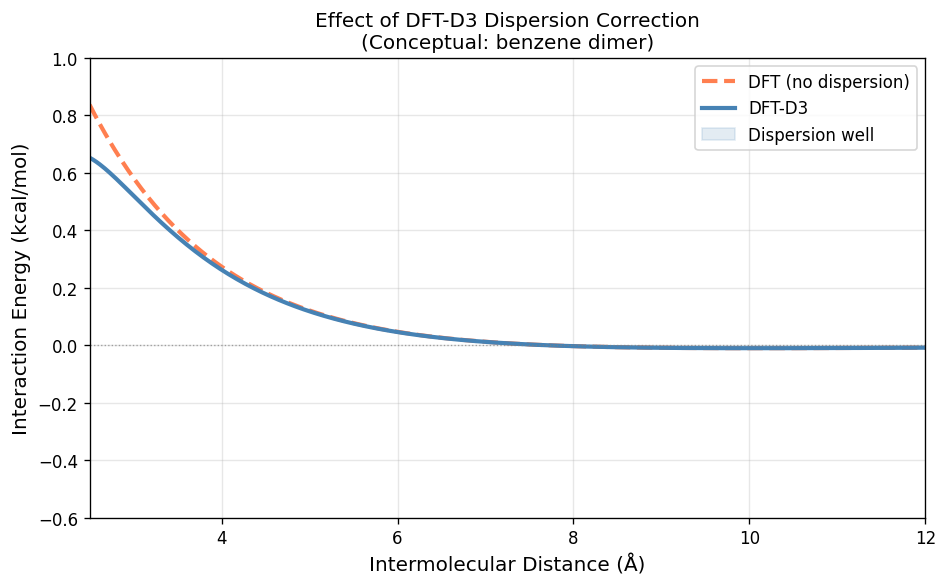

DFT-D3 Dispersion Correction Summary:
  ΔE_disp = -Σ_{i<j} s₆ C₆ᵢʲ/r₆ + s₈ C₈ᵢʲ/r₈  (with damping function)

Usage in PySCF:
  mf = dft.RKS(mol)
  mf.xc = 'B3LYP'
  from pyscf import dftd3  # requires dftd3 Python bindings
  mf = dftd3.dftd3(mf)    # wraps mf with D3 correction

Usage in ORCA:
  ! B3LYP-D3BJ def2-SVP Opt
  ! PBE0-D3/def2-TZVP Energy

Common dispersion variants:
  -D3(BJ): Becke-Johnson damping (recommended for most systems)
  -D3(0):  Zero-damping (Grimme 2010, original)
  -D4:     Charge-dependent, more accurate for ionic systems


In [16]:
# ------------------------------------------------------------------
# DFT-D3 Dispersion Correction
# ------------------------------------------------------------------
# Standard DFT functionals miss van der Waals / London dispersion
# interactions. Grimme's DFT-D3 correction adds pairwise C6/r^6 terms.

import numpy as np
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt

# Conceptual: Lennard-Jones-like comparison
r = np.linspace(2.5, 12, 500)   # Angstrom

# Approximate DFT (no dispersion) for benzene dimer: flat near repulsion, no well
def dft_nodispersion(r):
    # Simplified: Pauli repulsion only, very shallow
    return 5.0 * np.exp(-r/1.5) - 0.2 * np.exp(-r/4.0)

# With D3 correction: adds -C6/r^6 term
def dft_d3(r, C6=45.0, s6=1.0):
    return dft_nodispersion(r) - s6 * C6 / r**6

E_nodis = dft_nodispersion(r)
E_d3 = dft_d3(r)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r, E_nodis, '--', color='coral', linewidth=2.5, label='DFT (no dispersion)')
ax.plot(r, E_d3, '-', color='steelblue', linewidth=2.5, label='DFT-D3')
ax.axhline(y=0, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)
ax.fill_between(r, E_d3, 0, where=(E_d3 < 0), alpha=0.15, color='steelblue',
                label='Dispersion well')
ax.set_xlim(2.5, 12)
ax.set_ylim(-0.6, 1.0)
ax.set_xlabel('Intermolecular Distance (Å)', fontsize=12)
ax.set_ylabel('Interaction Energy (kcal/mol)', fontsize=12)
ax.set_title('Effect of DFT-D3 Dispersion Correction\n(Conceptual: benzene dimer)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("DFT-D3 Dispersion Correction Summary:")
print("  ΔE_disp = -Σ_{i<j} s₆ C₆ᵢʲ/r₆ + s₈ C₈ᵢʲ/r₈  (with damping function)")
print()
print("Usage in PySCF:")
print("  mf = dft.RKS(mol)")
print("  mf.xc = 'B3LYP'")
print("  from pyscf import dftd3  # requires dftd3 Python bindings")
print("  mf = dftd3.dftd3(mf)    # wraps mf with D3 correction")
print()
print("Usage in ORCA:")
print("  ! B3LYP-D3BJ def2-SVP Opt")
print("  ! PBE0-D3/def2-TZVP Energy")
print()
print("Common dispersion variants:")
print("  -D3(BJ): Becke-Johnson damping (recommended for most systems)")
print("  -D3(0):  Zero-damping (Grimme 2010, original)")
print("  -D4:     Charge-dependent, more accurate for ionic systems")

## 2. DFT Functional Reference Table

| Functional | Type | %HF Exchange | Dispersion | Cost | Accuracy | Good For | Caution |
|------------|------|:---:|:---:|:---:|:---:|---------|----------|
| SVWN | LDA | 0 | ✗ | ★ | ★★ | Solids, quick tests | Overbinds molecules |
| PBE | GGA | 0 | ✗ | ★★ | ★★★ | Solids, surfaces | Self-interaction |
| BLYP | GGA | 0 | ✗ | ★★ | ★★★ | Organics | Dispersion missing |
| TPSS | meta-GGA | 0 | ✗ | ★★★ | ★★★ | General chemistry | Slow |
| M06-L | meta-GGA | 0 | ✗ | ★★★ | ★★★★ | Transition metals | Sensitive to grid |
| B3LYP | Hybrid | 20 | ✗ | ★★★ | ★★★★ | Organics, pharmacy | No dispersion; fails TM |
| B3LYP-D3 | Hybrid+D | 20 | ✓ | ★★★ | ★★★★ | General organics | TM still tricky |
| PBE0 | Hybrid | 25 | ✗ | ★★★ | ★★★★ | General chemistry | Dispersion missing |
| PBE0-D3 | Hybrid+D | 25 | ✓ | ★★★ | ★★★★★ | **Recommended** | |
| r2scan-3c | Composite meta-GGA |  | ✓ | ★★★ | ★★★★★ | **Recommended** | |
| TPSSh | Hybrid | 10 | ✗ | ★★★ | ★★★★ | Transition metals | |
| M06 | Hybrid | 27 | ✗ | ★★★★ | ★★★★ | Main group + TM | Sensitive to grid |
| M06-2X | Hybrid | 54 | ✗ | ★★★★ | ★★★★★ | Thermochem, kinetics | Fails for TM |
| ωB97X-D | Range-sep | var | ✓ | ★★★★ | ★★★★★ | CT excitations, NCI | Expensive |
| CAM-B3LYP | Range-sep | var | ✗ | ★★★★ | ★★★★ | CT, long-range | |
| B2-PLYP | Double hybrid | 53 | ✗ | ★★★★★ | ★★★★★ | High accuracy | Very expensive |

_One favorite paper_ 
**Best-Practice DFT Protocols for Basic Molecular Computational Chemistry**, Bursch et al. 
https://doi.org/10.1002/anie.202205735 Open access 

**Some recommendations:**
- **Geometry optimization**: `B3LYP/def2-SVP` or `r2scan-3c/def2-SVP`
- **Reaction Energies**: `ωB97 (X/V/M/D4) variants - def2-QZVP` or `r2scan-3c/def2-TZVP`
- **Transition metals**: `TPSSh/def2-SVP` or `M06/def2-SVP`
- **Excited states**: `CAM-B3LYP/def2-SVP` (TD-DFT)

## 🔬 Research Connection

DFT is the workhorse of modern computational chemistry and materials science:

- **~50% of all computational chemistry papers** use DFT (B3LYP alone has >100,000 citations)
- **Drug design**: DFT computes binding site interactions, reaction mechanisms in metalloenzymes
- **Heterogeneous catalysis**: PBE/plane-waves for surface reactions (e.g., CO₂ reduction)
- **Battery materials**: DFT predicts lithium intercalation energies in electrode materials
- **Nobel Prizes**: Kohn (1998 Chemistry), Karplus/Levitt/Warshel (2013 Chemistry)

**The DFT accuracy crisis**: B3LYP was found to fail for dispersion-dominated systems,
kinetics (reaction barriers), and transition metal complexes. This drove development
of M06-2X, ωB97X-D, and dispersion corrections, now standard in publications.

## 📋 Summary

| Concept | Key Points |
|---------|----------|
| HK Theorem 1 | Ground state energy is a unique functional of $n_0(\mathbf{r})$ |
| HK Theorem 2 | Variational principle: true $n_0$ minimizes $E[n]$ |
| Kohn-Sham DFT | Non-interacting reference with same density; same structure as HF |
| LDA | Uses only $n(\mathbf{r})$; overbinds; good for solids |
| GGA | Adds $\nabla n$; better for molecules; missing dispersion |
| Hybrid | Mixes HF exchange; best for most molecular applications |
| Dispersion | -D3(BJ) adds $C_6/r^6$ correction; always use for weak interactions |

**When DFT works well:** Geometries (±0.01-0.02 Å), reaction energies (±2 kcal/mol),
vibrational frequencies, dipole moments, NMR shifts

**When DFT struggles:** Strong correlation (multi-reference), charge-transfer excitations (without range-separation), dispersion (without correction), delocalization error

## 📝 Exercises

1. **Jacob's Ladder**: For each rung (LDA, GGA, meta-GGA, hybrid), name one functional
   not listed in the notebook. Look up its year of publication and the journal it appeared in.

2. **Functional comparison**: Run the water functional comparison with `aug-cc-pVTZ`
   instead of `def2-SVP`. Does the ordering of energies change? Why might it?

3. **Dispersion in benzene dimer**: Using PySCF, compute the interaction energy of
   two benzene molecules (face-to-face at 3.8 Å) with B3LYP/6-31G* (no dispersion).
   What sign is the interaction? Is this physical?

4. **Exact exchange fraction**: B3LYP uses 20% HF exchange. Try changing this using
   `mf.xc = '0.15*HF + 0.85*B88, LYP'` and `mf.xc = '0.30*HF + 0.70*B88, LYP'`.
   How do the energy and dipole moment of water change?

5. **DFT vs HF correlation energy**: Compare the energy of H₂O computed by
   RHF/def2-SVP and PBE/def2-SVP. The difference approximates how much correlation
   energy DFT captures. How does this compare to the MP2 correlation energy?

#1

LDA: Hedin-Lundqvist LDA, published in 1971 in Journal of Physics C: Solid State Physics.
GGA: RPBE, published in 1999 in Physical Review B.
meta-GGA: PKZB, published in 1999 in Physical Review Letters.
Hybrid: MPW1K, published in 2004 in The Journal of Physical Chemistry A.
LDA uses only the local density, GGA adds the density gradient, meta-GGA adds orbital-dependent ingredients such as kinetic energy density, and hybrid functionals mix in some Hartree-Fock exact exchange.

SVWN     (LDA       ): E = -75.90532051 Ha   μ = 1.856 D
PBE      (GGA       ): E = -76.38005402 Ha   μ = 1.795 D
TPSS     (meta-GGA  ): E = -76.46648408 Ha   μ = 1.804 D
B3LYP    (Hybrid    ): E = -76.46614490 Ha   μ = 1.853 D
PBE0     (Hybrid    ): E = -76.37998935 Ha   μ = 1.858 D

DFT Functional Comparison: H2O / aug-cc-pVTZ
Functional Category  Energy (Ha)  Dipole (D)
      SVWN      LDA   -75.905321    1.856287
       PBE      GGA   -76.380054    1.795450
      TPSS meta-GGA   -76.466484    1.804111
     B3LYP   Hybrid   -76.466145    1.853405
      PBE0   Hybrid   -76.379989    1.858204

Energy ordering from lowest to highest energy:
TPSS < B3LYP < PBE < PBE0 < SVWN

Previous def2-SVP ordering:
TPSS < B3LYP < PBE0 < PBE < SVWN

New aug-cc-pVTZ ordering:
TPSS < B3LYP < PBE < PBE0 < SVWN

Conclusion: The energy ordering DID change.


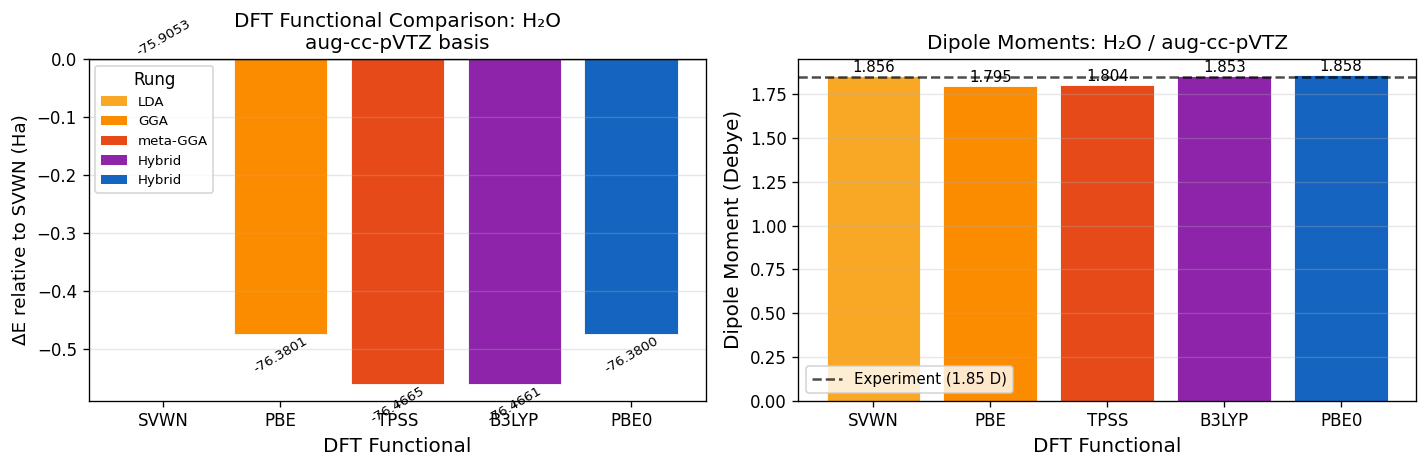

In [21]:
# ------------------------------------------------------------------
# DFT Functional Comparison on H2O / aug-cc-pVTZ
# ------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyscf import gto, dft
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Build water molecule
# ------------------------------------------------------------------
mol = gto.Mole()
mol.atom = '''O  0.000000  0.000000  0.117176
H  0.000000  0.757001 -0.468704
H  0.000000 -0.757001 -0.468704'''
mol.basis = 'aug-cc-pVTZ'
mol.verbose = 0
mol.build()

# ------------------------------------------------------------------
# Functionals to compare
# ------------------------------------------------------------------
functionals = {
    'SVWN':  ('LDA',       '#F9A825'),
    'PBE':   ('GGA',       '#FB8C00'),
    'TPSS':  ('meta-GGA',  '#E64A19'),
    'B3LYP': ('Hybrid',    '#8E24AA'),
    'PBE0':  ('Hybrid',    '#1565C0'),
}

# ------------------------------------------------------------------
# Run calculations
# ------------------------------------------------------------------
results = []

for func, (category, color) in functionals.items():
    mf = dft.RKS(mol)
    mf.xc = func
    mf.verbose = 0

    e = mf.kernel()

    dm = mf.make_rdm1()
    dip = mf.dip_moment(mol, dm, verbose=0)
    dip_mag = np.linalg.norm(dip)

    results.append({
        'Functional': func,
        'Category': category,
        'Energy (Ha)': e,
        'Dipole (D)': dip_mag,
        'Color': color
    })

    print(f"{func:8s} ({category:10s}): E = {e:.8f} Ha   μ = {dip_mag:.3f} D")

df_aug = pd.DataFrame(results)

# ------------------------------------------------------------------
# Print table
# ------------------------------------------------------------------
print("\nDFT Functional Comparison: H2O / aug-cc-pVTZ")
print(df_aug[['Functional', 'Category', 'Energy (Ha)', 'Dipole (D)']].to_string(index=False))

# ------------------------------------------------------------------
# Sort by total energy
# ------------------------------------------------------------------
df_sorted = df_aug.sort_values("Energy (Ha)")

print("\nEnergy ordering from lowest to highest energy:")
print(" < ".join(df_sorted["Functional"].tolist()))

# ------------------------------------------------------------------
# Compare to previous def2-SVP ordering from your earlier run
# Earlier energies:
# SVWN  = -75.795146
# PBE   = -76.271966
# TPSS  = -76.360001
# B3LYP = -76.358122
# PBE0  = -76.276252
# ------------------------------------------------------------------
def2_svp_energies = {
    'SVWN':  -75.795146,
    'PBE':   -76.271966,
    'TPSS':  -76.360001,
    'B3LYP': -76.358122,
    'PBE0':  -76.276252,
}

def2_order = sorted(def2_svp_energies, key=def2_svp_energies.get)
aug_order = df_sorted["Functional"].tolist()

print("\nPrevious def2-SVP ordering:")
print(" < ".join(def2_order))

print("\nNew aug-cc-pVTZ ordering:")
print(" < ".join(aug_order))

if aug_order == def2_order:
    print("\nConclusion: The energy ordering did NOT change.")
else:
    print("\nConclusion: The energy ordering DID change.")

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

energies = df_aug['Energy (Ha)'].values
funcs = df_aug['Functional'].values
colors_list = df_aug['Color'].values

# Energy relative to SVWN
E_ref = df_aug.loc[df_aug["Functional"] == "SVWN", "Energy (Ha)"].values[0]
delta_E = energies - E_ref

bars1 = ax1.bar(funcs, delta_E, color=colors_list, edgecolor='white', linewidth=0.5)

ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.set_xlabel('DFT Functional', fontsize=12)
ax1.set_ylabel('ΔE relative to SVWN (Ha)', fontsize=11)
ax1.set_title('DFT Functional Comparison: H₂O\naug-cc-pVTZ basis', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

for bar, e in zip(bars1, energies):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{e:.4f}',
        ha='center',
        va='bottom' if bar.get_height() >= 0 else 'top',
        fontsize=8,
        rotation=30
    )

# Dipoles
dipoles = df_aug['Dipole (D)'].values

bars2 = ax2.bar(funcs, dipoles, color=colors_list, edgecolor='white', linewidth=0.5)

ax2.axhline(y=1.85, color='black', linestyle='--', alpha=0.7, label='Experiment (1.85 D)')
ax2.set_xlabel('DFT Functional', fontsize=12)
ax2.set_ylabel('Dipole Moment (Debye)', fontsize=12)
ax2.set_title('Dipole Moments: H₂O / aug-cc-pVTZ', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

for bar, d in zip(bars2, dipoles):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{d:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

legend_elements = [
    Patch(facecolor='#F9A825', label='LDA'),
    Patch(facecolor='#FB8C00', label='GGA'),
    Patch(facecolor='#E64A19', label='meta-GGA'),
    Patch(facecolor='#8E24AA', label='Hybrid'),
    Patch(facecolor='#1565C0', label='Hybrid'),
]

ax1.legend(handles=legend_elements, fontsize=8, title='Rung')

plt.tight_layout()
plt.show()

A basis set controls how flexibly the molecular orbitals and electron density can be represented. In an LCAO calculation, each molecular orbital is expanded as a linear combination of basis functions, so changing the basis changes the allowed space for the electron density and orbitals.

So the only change is that PBE and PBE0 switched order.

This switch is very small. With aug-cc-pVTZ, the PBE energy is -76.38005402 Ha and the PBE0 energy is -76.37998935 Ha. The difference is only 0.00006467 Ha, which is about 0.041 kcal/mol. This is far below 1 kcal/mol chemical accuracy, so the change is best interpreted as a near-tie being flipped rather than a major physical result.

The ordering can change because the basis set changes how flexibly the orbitals and electron density are described. aug-cc-pVTZ is larger than def2-SVP and includes diffuse functions, so it gives a more flexible description of the electron density. Different functionals respond differently to this increased flexibility. PBE is a GGA functional, while PBE0 is a hybrid functional that includes some Hartree-Fock exact exchange. Because their exchange-correlation formulas are different, their total energies do not shift by exactly the same amount when the basis set is changed.

However, lower total energy does not mean a functional is automatically more accurate. Different DFT functionals use different approximate exchange-correlation energy expressions, so absolute total energies from different functionals should not be ranked as “better” just because they are lower.

The dipole moments are a more useful comparison here. With aug-cc-pVTZ, the calculated dipoles are much closer to the experimental water dipole of about 1.85 D. B3LYP gives 1.853 D and PBE0 gives 1.858 D, both very close to experiment. This suggests that the larger basis improves the molecular property calculation, even though the absolute energy ordering only changes by a tiny amount.

In [22]:
# ------------------------------------------------------------------
# Benzene dimer interaction energy with B3LYP/6-31G*
# Face-to-face geometry, separation = 3.8 Angstrom
# No dispersion correction
# ------------------------------------------------------------------

import numpy as np
from pyscf import gto, dft

HARTREE_TO_KCAL = 627.509474

# ------------------------------------------------------------------
# Build planar benzene coordinates
# ------------------------------------------------------------------
# Benzene is placed in the xy-plane.
# Carbon atoms form a regular hexagon.
# Hydrogens are placed radially outward.

def benzene_xyz(z_shift=0.0):
    """
    Return benzene coordinates as a list of strings.

    z_shift moves the whole benzene molecule along the z-axis.
    """
    coords = []

    r_C = 1.397   # approximate C radius from ring center, Angstrom
    r_H = 2.481   # approximate H radius from ring center, Angstrom

    for i in range(6):
        theta = 2 * np.pi * i / 6

        x_C = r_C * np.cos(theta)
        y_C = r_C * np.sin(theta)

        x_H = r_H * np.cos(theta)
        y_H = r_H * np.sin(theta)

        coords.append(f"C  {x_C: .8f}  {y_C: .8f}  {z_shift: .8f}")
        coords.append(f"H  {x_H: .8f}  {y_H: .8f}  {z_shift: .8f}")

    return coords


# ------------------------------------------------------------------
# Function to run B3LYP/6-31G*
# ------------------------------------------------------------------
def run_b3lyp(atom_lines, label):
    """
    Runs a B3LYP/6-31G* single-point calculation.

    atom_lines: list of atom-coordinate strings
    label: name printed for the calculation
    """
    mol = gto.Mole()
    mol.atom = "\n".join(atom_lines)
    mol.basis = "6-31g*"
    mol.unit = "Angstrom"
    mol.charge = 0
    mol.spin = 0
    mol.verbose = 0
    mol.build()

    mf = dft.RKS(mol)
    mf.xc = "B3LYP"
    mf.verbose = 0

    # These settings make DFT numerical integration more stable.
    mf.grids.level = 3

    energy = mf.kernel()

    print(f"{label:20s} E = {energy:.10f} Ha")
    return energy


# ------------------------------------------------------------------
# Build monomer and dimer
# ------------------------------------------------------------------
separation = 3.8

# Put monomers at z = -1.9 and z = +1.9, so distance = 3.8 A
benzene_A = benzene_xyz(z_shift=-separation / 2)
benzene_B = benzene_xyz(z_shift= separation / 2)

# Monomer energy: one benzene molecule
benzene_monomer = benzene_xyz(z_shift=0.0)

# Dimer energy: two benzene molecules
benzene_dimer = benzene_A + benzene_B


# ------------------------------------------------------------------
# Run calculations
# ------------------------------------------------------------------
E_monomer = run_b3lyp(benzene_monomer, "Benzene monomer")
E_dimer   = run_b3lyp(benzene_dimer,   "Benzene dimer")


# ------------------------------------------------------------------
# Interaction energy
# ------------------------------------------------------------------
E_int_Ha = E_dimer - 2 * E_monomer
E_int_kcal = E_int_Ha * HARTREE_TO_KCAL

print("\nInteraction energy:")
print(f"E_int = E_dimer - 2 E_monomer")
print(f"E_int = {E_int_Ha:.10f} Ha")
print(f"E_int = {E_int_kcal:.4f} kcal/mol")

if E_int_Ha < 0:
    print("\nSign: negative")
    print("Interpretation: attractive interaction")
else:
    print("\nSign: positive")
    print("Interpretation: repulsive interaction")

Benzene monomer      E = -232.2437937604 Ha
Benzene dimer        E = -464.4844334061 Ha

Interaction energy:
E_int = E_dimer - 2 E_monomer
E_int = 0.0031541147 Ha
E_int = 1.9792 kcal/mol

Sign: positive
Interpretation: repulsive interaction


The interaction energy is positive:

E_int = +0.003154 Ha = +1.98 kcal/mol.

Therefore, B3LYP/6-31G* without dispersion predicts the face-to-face benzene dimer to be repulsive at 3.8 Å.

This is not physically correct. A benzene dimer should be weakly attractive because stacked aromatic rings are stabilized mainly by London dispersion interactions. Plain B3LYP does not include a proper long-range dispersion correction, so it misses this attraction and gives a positive interaction energy.
A more physical calculation would use a dispersion-corrected functional such as B3LYP-D3(BJ), B3LYP-D4, ωB97X-D, or r2SCAN-3c.

In [1]:
import pyscf
import pyscf.dispersion

print("PySCF version:", pyscf.__version__)
print("pyscf-dispersion is available")

PySCF version: 2.13.0
pyscf-dispersion is available


In [2]:
# ------------------------------------------------------------------
# Benzene dimer interaction energy:
# Plain B3LYP vs dispersion-corrected DFT in PySCF
#
# Requires:
#     pip install pyscf-dispersion
#
# Important:
#     Restart Jupyter kernel after installing pyscf-dispersion.
# ------------------------------------------------------------------

import numpy as np
import pandas as pd
from pyscf import gto

HARTREE_TO_KCAL = 627.509474


# ------------------------------------------------------------------
# Build benzene coordinates
# ------------------------------------------------------------------
def benzene_xyz(z_shift=0.0):
    """
    Build one benzene molecule in the xy-plane.

    z_shift moves the whole molecule along the z-axis.
    Units: Angstrom.
    """
    coords = []

    r_C = 1.397   # carbon distance from benzene center
    r_H = 2.481   # hydrogen distance from benzene center

    for i in range(6):
        theta = 2 * np.pi * i / 6

        x_C = r_C * np.cos(theta)
        y_C = r_C * np.sin(theta)

        x_H = r_H * np.cos(theta)
        y_H = r_H * np.sin(theta)

        coords.append(f"C  {x_C: .8f}  {y_C: .8f}  {z_shift: .8f}")
        coords.append(f"H  {x_H: .8f}  {y_H: .8f}  {z_shift: .8f}")

    return coords


# ------------------------------------------------------------------
# Build PySCF molecule
# ------------------------------------------------------------------
def make_mol(atom_lines, basis="6-31g*"):
    """
    Convert atom-coordinate strings into a PySCF molecule object.
    """
    mol = gto.Mole()

    mol.atom = "\n".join(atom_lines)
    mol.basis = basis
    mol.unit = "Angstrom"

    mol.charge = 0
    mol.spin = 0

    mol.verbose = 0
    mol.build()

    return mol


# ------------------------------------------------------------------
# Run DFT calculation
# ------------------------------------------------------------------
def run_dft(atom_lines, xc, basis="6-31g*", label="calculation"):
    """
    Run a restricted Kohn-Sham DFT calculation.

    xc can be:
        "B3LYP"
        "b3lyp-d3bj"
        "b3lyp-d4"
        "wb97x-d4"
    """
    mol = make_mol(atom_lines, basis=basis)

    # This is the corrected syntax.
    # mol.KS(xc=...) lets PySCF recognize dispersion keywords
    # after pyscf-dispersion is installed.
    mf = mol.KS(xc=xc)

    mf.grids.level = 3
    mf.verbose = 0

    energy = mf.kernel()

    print(f"{label:20s} {xc:12s} E = {energy:.10f} Ha")

    return energy


# ------------------------------------------------------------------
# Interaction energy
# ------------------------------------------------------------------
def interaction_energy(E_dimer, E_monomer):
    """
    Compute supermolecular interaction energy.

    E_int = E_dimer - 2 E_monomer

    Negative means attractive.
    Positive means repulsive.
    """
    E_int_Ha = E_dimer - 2 * E_monomer
    E_int_kcal = E_int_Ha * HARTREE_TO_KCAL

    return E_int_Ha, E_int_kcal


# ------------------------------------------------------------------
# Geometry setup
# ------------------------------------------------------------------
separation = 3.8   # Angstrom

benzene_monomer = benzene_xyz(z_shift=0.0)

benzene_A = benzene_xyz(z_shift=-separation / 2)
benzene_B = benzene_xyz(z_shift= separation / 2)

benzene_dimer = benzene_A + benzene_B


# ------------------------------------------------------------------
# Methods to test
# ------------------------------------------------------------------
methods = [
    ("B3LYP", "No dispersion"),
    ("b3lyp-d3bj", "D3(BJ)"),
    ("b3lyp-d4", "D4"),
    ("wb97x-d4", "D4"),
]


# ------------------------------------------------------------------
# Run calculations
# ------------------------------------------------------------------
results = []

for xc, dispersion_label in methods:
    print("\n" + "=" * 72)
    print(f"Running method: {xc}")
    print("=" * 72)

    try:
        E_monomer = run_dft(
            benzene_monomer,
            xc=xc,
            basis="6-31g*",
            label="Benzene monomer"
        )

        E_dimer = run_dft(
            benzene_dimer,
            xc=xc,
            basis="6-31g*",
            label="Benzene dimer"
        )

        E_int_Ha, E_int_kcal = interaction_energy(E_dimer, E_monomer)

        if E_int_kcal < 0:
            sign = "negative / attractive"
        else:
            sign = "positive / repulsive"

        results.append({
            "Method": xc,
            "Dispersion": dispersion_label,
            "E_monomer (Ha)": E_monomer,
            "E_dimer (Ha)": E_dimer,
            "E_int (Ha)": E_int_Ha,
            "E_int (kcal/mol)": E_int_kcal,
            "Sign": sign
        })

    except Exception as err:
        print(f"\n{xc} skipped.")
        print("Error message:")
        print(err)


# ------------------------------------------------------------------
# Final table
# ------------------------------------------------------------------
df = pd.DataFrame(results)

print("\n")
print("=" * 100)
print("Benzene Dimer Interaction Energies")
print("=" * 100)

if len(df) > 0:
    print(df.to_string(index=False))

    print("\nInterpretation:")
    for _, row in df.iterrows():
        print(
            f"{row['Method']:12s}: "
            f"E_int = {row['E_int (kcal/mol)']: .4f} kcal/mol "
            f"({row['Sign']})"
        )
else:
    print("No calculations completed.")


Running method: B3LYP
Benzene monomer      B3LYP        E = -232.2437937604 Ha
Benzene dimer        B3LYP        E = -464.4844334061 Ha

Running method: b3lyp-d3bj
Benzene monomer      b3lyp-d3bj   E = -232.2627009970 Ha
Benzene dimer        b3lyp-d3bj   E = -464.5301880042 Ha

Running method: b3lyp-d4
Benzene monomer      b3lyp-d4     E = -232.2611227397 Ha
Benzene dimer        b3lyp-d4     E = -464.5278021306 Ha

Running method: wb97x-d4
Benzene monomer      wb97x-d4     E = -232.1978598176 Ha
Benzene dimer        wb97x-d4     E = -464.4038232221 Ha


Benzene Dimer Interaction Energies
    Method    Dispersion  E_monomer (Ha)  E_dimer (Ha)  E_int (Ha)  E_int (kcal/mol)                  Sign
     B3LYP No dispersion     -232.243794   -464.484433    0.003154          1.979237  positive / repulsive
b3lyp-d3bj        D3(BJ)     -232.262701   -464.530188   -0.004786         -3.003267 negative / attractive
  b3lyp-d4            D4     -232.261123   -464.527802   -0.005557         -3.48685

In [23]:
# ------------------------------------------------------------------
# Effect of exact HF exchange fraction on H2O
# ------------------------------------------------------------------

import numpy as np
import pandas as pd
from pyscf import gto, dft

# Conversion
HARTREE_TO_KCAL = 627.509474

# ------------------------------------------------------------------
# Build water molecule
# ------------------------------------------------------------------
mol = gto.Mole()
mol.atom = '''O  0.000000  0.000000  0.117176
H  0.000000  0.757001 -0.468704
H  0.000000 -0.757001 -0.468704'''
mol.basis = 'def2-SVP'      # keep same basis as earlier notebook
mol.unit = 'Angstrom'
mol.verbose = 0
mol.build()

# ------------------------------------------------------------------
# Custom hybrid functionals
# ------------------------------------------------------------------
functionals = {
    "15% HF": "0.15*HF + 0.85*B88, LYP",
    "20% HF": "0.20*HF + 0.80*B88, LYP",   # B3LYP-like exchange fraction, not full canonical B3LYP
    "30% HF": "0.30*HF + 0.70*B88, LYP",
}

results = []

for label, xc_string in functionals.items():
    mf = dft.RKS(mol)
    mf.xc = xc_string
    mf.verbose = 0

    energy = mf.kernel()

    dm = mf.make_rdm1()
    dipole_vector = mf.dip_moment(mol, dm, verbose=0)
    dipole_mag = np.linalg.norm(dipole_vector)

    results.append({
        "Functional": label,
        "XC string": xc_string,
        "Energy (Ha)": energy,
        "Dipole (D)": dipole_mag
    })

    print(f"{label:8s}  E = {energy:.10f} Ha   μ = {dipole_mag:.4f} D")

df_exchange = pd.DataFrame(results)

# ------------------------------------------------------------------
# Add relative energies
# ------------------------------------------------------------------
E_ref = df_exchange.loc[df_exchange["Functional"] == "20% HF", "Energy (Ha)"].values[0]

df_exchange["ΔE vs 20% HF (Ha)"] = df_exchange["Energy (Ha)"] - E_ref
df_exchange["ΔE vs 20% HF (kcal/mol)"] = df_exchange["ΔE vs 20% HF (Ha)"] * HARTREE_TO_KCAL

print("\nExact exchange fraction comparison:")
print(
    df_exchange[
        ["Functional", "Energy (Ha)", "ΔE vs 20% HF (kcal/mol)", "Dipole (D)"]
    ].to_string(index=False)
)

15% HF    E = -76.3305176190 Ha   μ = 1.9569 D
20% HF    E = -76.3286007090 Ha   μ = 1.9712 D
30% HF    E = -76.3248611356 Ha   μ = 1.9990 D

Exact exchange fraction comparison:
Functional  Energy (Ha)  ΔE vs 20% HF (kcal/mol)  Dipole (D)
    15% HF   -76.330518                -1.202879    1.956882
    20% HF   -76.328601                 0.000000    1.971169
    30% HF   -76.324861                 2.346618    1.998971


Increasing the exact HF exchange fraction from 15% to 30% makes the total energy less negative and increases the dipole moment of water. The energy changes from -76.330518 Ha at 15% HF to -76.324861 Ha at 30% HF, so the 30% HF calculation is higher in energy than the 20% HF case by about 2.35 kcal/mol. The dipole moment increases from 1.9569 D to 1.9990 D, meaning the electron density becomes more polarized as more exact exchange is added. This happens because HF exchange is nonlocal and reduces some self-interaction error, which changes the self-consistent electron density. Overall, for this water calculation, increasing the HF exchange fraction gives a higher total energy and a larger dipole moment.

In [24]:
# ------------------------------------------------------------------
# DFT vs HF correlation estimate for H2O / def2-SVP
# ------------------------------------------------------------------

from pyscf import gto, scf, dft, mp
import pandas as pd

HARTREE_TO_KCAL = 627.509474
HARTREE_TO_EV = 27.211386

# ------------------------------------------------------------------
# Build water molecule
# ------------------------------------------------------------------
mol = gto.Mole()
mol.atom = '''O  0.000000  0.000000  0.117176
H  0.000000  0.757001 -0.468704
H  0.000000 -0.757001 -0.468704'''
mol.basis = 'def2-SVP'
mol.unit = 'Angstrom'
mol.verbose = 0
mol.build()

# ------------------------------------------------------------------
# 1. RHF calculation
# ------------------------------------------------------------------
mf_hf = scf.RHF(mol)
mf_hf.verbose = 0
E_hf = mf_hf.kernel()

# ------------------------------------------------------------------
# 2. PBE calculation
# ------------------------------------------------------------------
mf_pbe = dft.RKS(mol)
mf_pbe.xc = 'PBE'
mf_pbe.verbose = 0
E_pbe = mf_pbe.kernel()

# ------------------------------------------------------------------
# 3. MP2 calculation using the RHF reference
# ------------------------------------------------------------------
mp2_calc = mp.MP2(mf_hf)
mp2_calc.verbose = 0
E_corr_mp2, t2 = mp2_calc.kernel()

E_mp2 = E_hf + E_corr_mp2

# ------------------------------------------------------------------
# Compare energy lowerings relative to RHF
# ------------------------------------------------------------------
E_pbe_minus_hf = E_pbe - E_hf
E_mp2_minus_hf = E_mp2 - E_hf

rows = [
    {
        "Method": "RHF",
        "Total Energy (Ha)": E_hf,
        "Energy lowering vs RHF (Ha)": 0.0,
        "Energy lowering vs RHF (kcal/mol)": 0.0
    },
    {
        "Method": "PBE",
        "Total Energy (Ha)": E_pbe,
        "Energy lowering vs RHF (Ha)": E_pbe_minus_hf,
        "Energy lowering vs RHF (kcal/mol)": E_pbe_minus_hf * HARTREE_TO_KCAL
    },
    {
        "Method": "MP2",
        "Total Energy (Ha)": E_mp2,
        "Energy lowering vs RHF (Ha)": E_mp2_minus_hf,
        "Energy lowering vs RHF (kcal/mol)": E_mp2_minus_hf * HARTREE_TO_KCAL
    }
]

df_corr = pd.DataFrame(rows)

print("H2O / def2-SVP: RHF vs PBE vs MP2")
print(df_corr.to_string(index=False))

print("\nKey quantities:")
print(f"E_RHF              = {E_hf:.10f} Ha")
print(f"E_PBE              = {E_pbe:.10f} Ha")
print(f"E_MP2              = {E_mp2:.10f} Ha")
print()
print(f"E_PBE - E_RHF      = {E_pbe_minus_hf:.10f} Ha")
print(f"                   = {E_pbe_minus_hf * HARTREE_TO_KCAL:.2f} kcal/mol")
print()
print(f"E_corr_MP2         = {E_corr_mp2:.10f} Ha")
print(f"                   = {E_corr_mp2 * HARTREE_TO_KCAL:.2f} kcal/mol")
print()

ratio = E_pbe_minus_hf / E_corr_mp2

print(f"Ratio: (E_PBE - E_RHF) / E_corr_MP2 = {ratio:.3f}")

if abs(E_pbe_minus_hf) > abs(E_corr_mp2):
    print("\nPBE lowers the energy more than MP2 relative to RHF.")
else:
    print("\nMP2 lowers the energy more than PBE relative to RHF.")

H2O / def2-SVP: RHF vs PBE vs MP2
Method  Total Energy (Ha)  Energy lowering vs RHF (Ha)  Energy lowering vs RHF (kcal/mol)
   RHF         -75.961013                     0.000000                           0.000000
   PBE         -76.271966                    -0.310953                        -195.125745
   MP2         -76.164572                    -0.203559                        -127.735132

Key quantities:
E_RHF              = -75.9610128480 Ha
E_PBE              = -76.2719655161 Ha
E_MP2              = -76.1645717382 Ha

E_PBE - E_RHF      = -0.3109526681 Ha
                   = -195.13 kcal/mol

E_corr_MP2         = -0.2035588902 Ha
                   = -127.74 kcal/mol

Ratio: (E_PBE - E_RHF) / E_corr_MP2 = 1.528

PBE lowers the energy more than MP2 relative to RHF.


PBE lowers the water energy more than MP2 relative to RHF, but the comparison is not one-to-one. MP2 correlation energy is defined relative to the RHF reference, so E_corr_MP2 = E_MP2 - E_RHF is a cleaner post-HF correlation correction. PBE, however, changes both the exchange and correlation treatment, so E_PBE - E_RHF is not pure correlation energy. It is better interpreted as the total energy lowering caused by replacing the HF exchange-only mean-field picture with a DFT exchange-correlation functional.